Using built-in math rendering with STIX fonts and system serif fonts

 *------------------------------------------------------------------------------------* 
 |                                                                                    | 
 |  *------------------------------------------------------------------------------*  | 
 |  |                                                                              |  | 
 |  |                                                                              |  | 
 |  |   PPP   Y   Y  TTTTT  H   H  III    A      Welcome to the Lund Monte Carlo!  |  | 
 |  |   P  P   Y Y     T    H   H   I    A A     This is PYTHIA version 8.312      |  | 
 |  |   PPP     Y      T    HHHHH   I   AAAAA    Last date of change: 23 May 2024  |  | 
 |  |   P       Y      T    H   H   I   A   A                                      |  | 
 |  |   P       Y      T    H   H  III  A   A    Now is 30 Jan 2026 at 11:33:00    |  | 
 |  |                                   

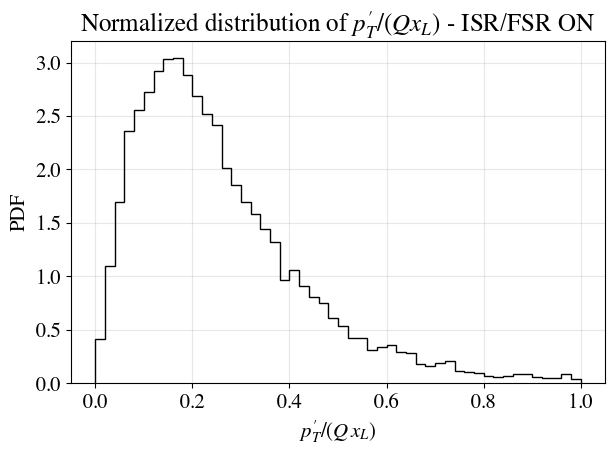

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings

# Suppress font warnings
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

# Configure matplotlib - using built-in math rendering to avoid LaTeX cache permission issues
# Use system serif fonts (Times, Times New Roman, etc.) with STIX for math
mpl.rcParams.update({
    "text.usetex": False,  # Disable LaTeX to avoid cache permission issues
    "font.family": "serif",
    "font.serif": ["Times", "Times New Roman", "DejaVu Serif", "serif"],  # Available serif fonts
    "mathtext.fontset": "stix",  # STIX fonts provide good quality math rendering
})
print("Using built-in math rendering with STIX fonts and system serif fonts")


# ISR and FSR ON - Fragmenting quark kT analysis
import pythia8
import numpy as np
import matplotlib.pyplot as plt

# ---------- helpers ----------
def dot(a, b):  # (+,-,-,-)
    return a[0]*b[0] - a[1]*b[1] - a[2]*b[2] - a[3]*b[3]

def is_hadron(pid):
    return abs(pid) >= 100  # any hadron

# ================== Pythia setup ==================
pythia = pythia8.Pythia()

# --------- EIC beams (choose one) ----------
Ee_set = 18.0     # electron beam energy [GeV]
Ep_set = 275.0    # proton beam energy   [GeV]
# Ee_set = 10.0; Ep_set = 100.0
# Ee_set = 5.0;  Ep_set = 41.0

pythia.readString("Beams:idA = 2212")   # proton
pythia.readString("Beams:idB = 11")     # electron
pythia.readString(f"Beams:eA = {Ep_set}")
pythia.readString(f"Beams:eB = {Ee_set}")
pythia.readString("Beams:frameType = 2")

# --------- DIS / NC exchange ----------
pythia.readString("WeakBosonExchange:ff2ff(t:gmZ) = on")  # NC DIS (gamma/Z)

# IMPORTANT: if you want *DIS events*, do NOT turn on generic HardQCD
pythia.readString("HardQCD:all = off")

# PDFs / showers / hadronization
pythia.readString("PDF:lepton = off")
pythia.readString("PartonLevel:ISR = on")
pythia.readString("PartonLevel:FSR = on")
pythia.readString("HadronLevel:all = on")

# Optional tuning-ish things
pythia.readString("ColourReconnection:reconnect = on")

# Generator-level Q2 cut (keep consistent with your analysis cuts)
pythia.readString("PhaseSpace:Q2Min = 16.0")   # e.g. Q > 4 GeV

pythia.init()


# Kinematic windows (EIC-friendly)
Qmin, Qmax = 5.0, 15.0
xmin, xmax = 1e-2, 0.5
n_events = 100_000  # adjust as needed

# Output container for fragmenting-quark transverse momentum (ISR/FSR ON)
kT_list_ISR_FSR_on = []
theta_list = []        # radians
theta_deg_list = []    # degrees
eta_list = [] # rapidity
x_list = []            # Bjorken x values
Q_list = []            # Q values

# Diagnostics
n_pass_evt = n_boost = 0
n_have_target = 0
printed_first_event = False  # Flag to print diagnostics once

# ================= EVENT LOOP =================
for iEvent in range(n_events):

    if not pythia.next():
        continue

    ev = pythia.event

    # Identify incoming e, scattered e, proton
    e_in = e_sc = p_in = None
    for p in ev:
        if p.id() == 11 and p.status() == -12: e_in = p
        elif p.id() == 11 and p.status() == 44: e_sc = p
        elif p.id() == 2212 and p.status() < 0: p_in = p

    if not (e_in and e_sc and p_in):
        continue

    Ee, Ep = e_in.e(), p_in.e()

    # Virtual photon
    q0 = e_in.e()  - e_sc.e()
    q1 = e_in.px() - e_sc.px()
    q2 = e_in.py() - e_sc.py()
    q3 = e_in.pz() - e_sc.pz()
    qmu = np.array([q0, q1, q2, q3])

    # Invariants
    Q2 = -(q0*q0 - q1*q1 - q2*q2 - q3*q3)
    if Q2 <= 0:
        continue

    Q = float(np.sqrt(Q2))
    qT = float(np.hypot(q1, q2))

    p_dot_q = Ep*q0 - Ep*q3
    if p_dot_q == 0: 
        continue

    x = Q2 / (2.0 * p_dot_q)
    if not (xmin <= x <= xmax):
        continue
    if not (Qmin <= Q <= Qmax):
        continue

    n_pass_evt += 1

    # Orientation angle for qT rotation
    phiq = float(np.arctan2(q2, q1))
    S = 4.0 * Ee * Ep
    y = Q2 / (S * x)  # inelasticity

    # ---------------- Build your Breit transform ----------------
    Mm1 = np.array([
        [Ee/np.sqrt(S) + np.sqrt(S)/(4.0*Ee), 0,0, Ee/np.sqrt(S) - np.sqrt(S)/(4.0*Ee)],
        [0,1,0,0],
        [0,0,1,0],
        [Ee/np.sqrt(S) - np.sqrt(S)/(4.0*Ee), 0,0, Ee/np.sqrt(S) + np.sqrt(S)/(4.0*Ee)]
    ])

    M0 = np.array([
        [1,0,0,0],
        [0, np.cos(phiq), np.sin(phiq), 0],
        [0,-np.sin(phiq), np.cos(phiq), 0],
        [0,0,0,1]
    ])

    denom_M1 = 2.0 * y * np.sqrt(S * (-qT*qT + S*(1+x)*y))
    if denom_M1 == 0:
        continue

    M1 = np.array([
        [(-qT*qT + S*y*(1+x+y)) / denom_M1, 0,0,
         ( qT*qT + S*y*(-x+y-1)) / denom_M1],
        [0,1,0,0],
        [0,0,1,0],
        [( qT*qT + S*y*(-x+y-1)) / denom_M1, 0,0,
         (-qT*qT + S*y*(1+x+y)) / denom_M1]
    ])

    den2 = (-qT*qT + S*(1+x)*y)
    if den2 <= 0:
        continue

    denom_M2_s1 = np.sqrt(S*(1+x)*y / den2)
    denom_M2_s2 = np.sqrt(S*(1+x)*y)

    M2 = np.array([
        [1,0,0,0],
        [0,1/denom_M2_s1,0, qT/denom_M2_s2],
        [0,0,1,0],
        [0,-qT/denom_M2_s2,0,1/denom_M2_s1]
    ])

    denom_M3 = np.sqrt(den2)
    num_log = qT + np.sqrt(S*(1+x)*y)
    den_log = np.sqrt(S*(1+x)*y) - qT
    if num_log <= 0 or den_log <= 0:
        continue

    eta = 0.5*np.log(num_log/den_log)
    M3 = np.array([
        [np.cosh(eta), -qT/denom_M3, 0,0],
        [-qT/denom_M3, np.cosh(eta), 0,0],
        [0,0,1,0],
        [0,0,0,1]
    ])

    denom_M4 = 2*np.sqrt(x*(1+x))
    if denom_M4 == 0:
        continue

    M4 = np.array([
        [(1+2*x)/denom_M4, 0,0, 1/denom_M4],
        [0,1,0,0],
        [0,0,1,0],
        [1/denom_M4, 0,0,(1+2*x)/denom_M4]
    ])

    # ---------------- Print diagnostics for first event ----------------
    if not printed_first_event:
        printed_first_event = True
        print("=" * 70)
        print("KINEMATIC VARIABLES (before boosts)")
        print("=" * 70)
        print(f"x  = {x:.10f}")
        print(f"y  = {y:.10f}")
        print(f"Q  = {Q:.10f} GeV")
        print(f"qT = {qT:.10f} GeV")
        print(f"phi = {phiq:.10f} radians")
        print(f"S  = {S:.10f} GeV²")
        print(f"Ei = Ee = {Ee:.10f} GeV")
        print(f"Ep = {Ep:.10f} GeV")
        print("=" * 70)
        print("\nMATRICES (for comparison with Mathematica):")
        print("\nMm1 =")
        print(Mm1)
        print("\nM0 =")
        print(M0)
        print("\nM1 =")
        print(M1)
        print("\nM2 =")
        print(M2)
        print("\nM3 =")
        print(M3)
        print("\nM4 =")
        print(M4)
        print()

    LT = M4 @ M3 @ M2 @ M1 @ M0 @ Mm1

    def boost(v): return LT @ np.array(v)

    n_boost += 1

    # ---------------- Verify Breit frame transformation ----------------
    # Boost photon and proton to Breit frame
    q_breit = boost(qmu)
    p_breit = boost([p_in.e(), p_in.px(), p_in.py(), p_in.pz()])
    
    # Print for first few events to verify
    if n_boost <= 10:
        print(f"\n=== Event {n_boost} ===")
        print(f"Lab frame - Q = {Q:.4f} GeV, x = {x:.4f}, qT = {qT:.4f} GeV")
        print(f"Photon (lab):     E={q0:8.4f}, px={q1:8.4f}, py={q2:8.4f}, pz={q3:8.4f}")
        print(f"Photon (Breit):   E={q_breit[0]:8.4f}, px={q_breit[1]:8.4f}, py={q_breit[2]:8.4f}, pz={q_breit[3]:8.4f}")
        print(f"  |q_Breit| = {np.sqrt(q_breit[1]**2 + q_breit[2]**2 + q_breit[3]**2):.4f} GeV (should be close to Q={Q:.4f})")
        print(f"Proton (lab):     E={p_in.e():8.4f}, px={p_in.px():8.4f}, py={p_in.py():8.4f}, pz={p_in.pz():8.4f}")
        print(f"Proton (Breit):   E={p_breit[0]:8.4f}, px={p_breit[1]:8.4f}, py={p_breit[2]:8.4f}, pz={p_breit[3]:8.4f}")
        print(f"  P+ (Breit) = {p_breit[0] + p_breit[3]:.4f} GeV")

    # ---------------- Tag target hadron ----------------
    best_E = -1.0
    best_lab = None
    best_trf = None

    for p in ev:
        if not p.isFinal(): 
            continue
        if not is_hadron(p.id()):
            continue

        # LAB 4-vector
        lab = np.array([p.e(), p.px(), p.py(), p.pz()])

        # Transform to Breit
        trf = boost(lab)
        E_, px_, py_, pz_ = trf

        if pz_ <= 0:
            continue  # require target hemisphere

        if E_ > best_E:
            best_E = E_
            best_lab = lab
            best_trf = trf

    if best_trf is None:
        continue

    n_have_target += 1

    # ---------------- Compute pT/Q/xL ----------------
    E_lab, px_lab, py_lab, pz_lab = best_lab
    xL = E_lab / Ep   # energy fraction in lab frame

    p_mag = np.sqrt(px_lab*px_lab + py_lab*py_lab + pz_lab*pz_lab)
    if p_mag <= 0:
        continue

    cos_theta = np.clip(pz_lab / p_mag, -1.0, 1.0)
    theta = float(np.arccos(cos_theta))          # radians
    theta_deg = theta * 180.0 / np.pi

    # pseudorapidity (best computed directly from pz and |p| to avoid tan issues)
    eta = float(0.5 * np.log((p_mag + pz_lab) / (p_mag - pz_lab + 1e-300)))

    theta_list.append(theta)
    theta_deg_list.append(theta_deg)
    eta_list.append(eta)

    E_, px_, py_, pz_ = best_trf
    pT = np.sqrt(px_*px_ + py_*py_)

    if xL > 0:
        kT = pT / (Q * xL)
        kT_list_ISR_FSR_on.append(kT)
    
    x_list.append(x)
    Q_list.append(Q)

# ================= PLOT =================
plt.figure()
plt.hist(kT_list_ISR_FSR_on, bins=50, range=(0,1),
         histtype="step", color="k", density=True)
plt.xlabel(r"$p_T'/(Q\,x_L)$")
plt.ylabel("PDF")
plt.title("Normalized distribution of $p_T'/(Q x_L)$ - ISR/FSR ON")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("kT_fragmenting_quark_normalized_ISR_FSR_on.png", dpi=180)


print("\nSummary (ISR/FSR ON):")
print(f"Events passing (x,Q): {n_pass_evt}")
print(f"Breit transforms:     {n_boost}")
print(f"Target hadrons:       {n_have_target}")
print(f"kT values:            {len(kT_list_ISR_FSR_on)}")


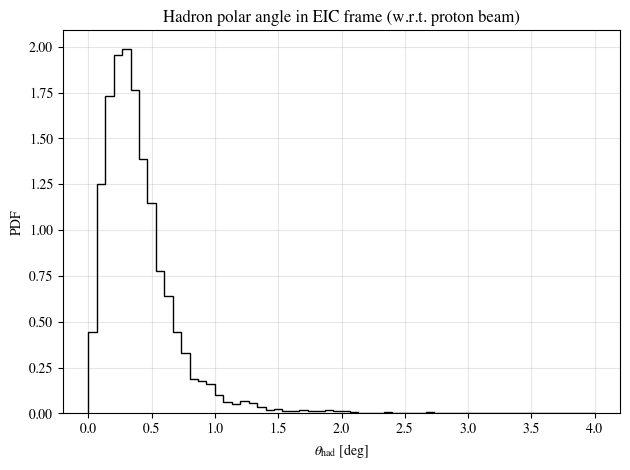

In [2]:
plt.figure()
plt.hist(theta_deg_list, bins=60, range=(0, 4),
         histtype="step", color="k", density=True)
plt.xlabel(r"$\theta_{\rm had}$ [deg]")
plt.ylabel("PDF")
plt.title("Hadron polar angle in EIC frame (w.r.t. proton beam)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("theta_hadron_EIC.png", dpi=180)

In [9]:
import matplotlib.patches as mpatches
import matplotlib as mpl
import numpy as np

# Use mathtext (built-in math renderer) instead of LaTeX
# This provides LaTeX-like syntax without requiring a full LaTeX installation
fontsize = 15  # Increased by 25% from 12
mpl.rcParams['text.usetex'] = False  # Use mathtext, not LaTeX
mpl.rcParams['mathtext.fontset'] = 'stix'  # High-quality math fonts
mpl.rcParams['font.size'] = fontsize
mpl.rcParams['axes.labelsize'] = fontsize
mpl.rcParams['xtick.labelsize'] = fontsize
mpl.rcParams['ytick.labelsize'] = fontsize
mpl.rcParams['legend.fontsize'] = fontsize

# Calculate average x and Q values
if len(x_list) > 0 and len(Q_list) > 0:
    avg_x = np.mean(x_list)
    avg_Q = np.mean(Q_list)
else:
    avg_x = 0.0
    avg_Q = 0.0

# Create figure and plot
fig, ax = plt.subplots()
ax.hist(eta_list, bins=80, range=(2, 8),
        histtype="step", color="k", density=True, linewidth=1.5)

# ---- EIC detector coverage ----
# B0 detector (4.6 < eta < 5.9)
ax.axvspan(4.6, 5.9, alpha=0.18, color="C0", zorder=0)
# Roman Pots + Off-Momentum Detectors (eta > 6)
ax.axvspan(6.0, 8.0, alpha=0.18, color="C0", zorder=0)

# ---- Labels ----
ax.set_xlabel(r"$\eta_{h}$", fontsize=fontsize)
ax.set_ylabel(r"$\dfrac{1}{\sigma} \dfrac{d\sigma}{d\eta_h}$", fontsize=fontsize)
ax.grid(False)

# Turn ticks inward
ax.tick_params(direction='in', labelsize=fontsize)

# ---- Legend ----
handles = [
    mpatches.Patch(color="C0", alpha=0.18, label=r"EIC coverage")
]
ax.legend(handles=handles, frameon=False, loc="upper left", fontsize=fontsize)

# Add <x> and <Q> text below the legend
if len(x_list) > 0 and len(Q_list) > 0:
    text_str = f"$\\langle x \\rangle = {avg_x:.4f}$\n$\\langle Q \\rangle = {avg_Q:.2f}$ GeV"
    ax.text(0.05, 0.87, text_str, transform=ax.transAxes,
            fontsize=fontsize, verticalalignment='top', horizontalalignment='left')

# Use subplots_adjust instead of tight_layout
plt.subplots_adjust(left=0.15, bottom=0.15, right=0.95, top=0.95)

plt.savefig("eta_hadron_EIC_hardware_QCD_regions.pdf", dpi=1000)
plt.close(fig)



 *------------------------------------------------------------------------------------* 
 |                                                                                    | 
 |  *------------------------------------------------------------------------------*  | 
 |  |                                                                              |  | 
 |  |                                                                              |  | 
 |  |   PPP   Y   Y  TTTTT  H   H  III    A  Processing 100000 events...
KINEMATIC VARIABLES (before boosts)
x  = 0.0100155002
y  = 0.2252423724
Q  = 6.6833462733 GeV
qT = 5.8827026016 GeV
phi = -2.2573189445 radians
S  = 19799.9999999743 GeV²
Ei = Ee = 17.9999959831 GeV
Ep = 275.0000613692 GeV

MATRICES (for comparison with Mathematica):

Mm1 =
[[ 2.08226074  0.          0.         -1.82641993]
 [ 0.          1.          0.          0.        ]
 [ 0.          0.          1.          0.        ]
 [-1.82641993  0.          0.          2.08226074]]



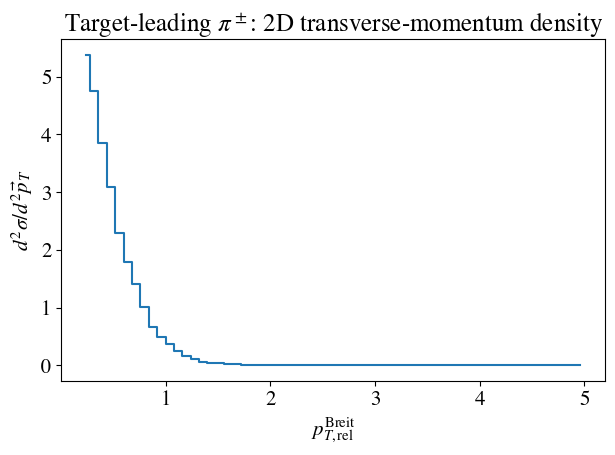

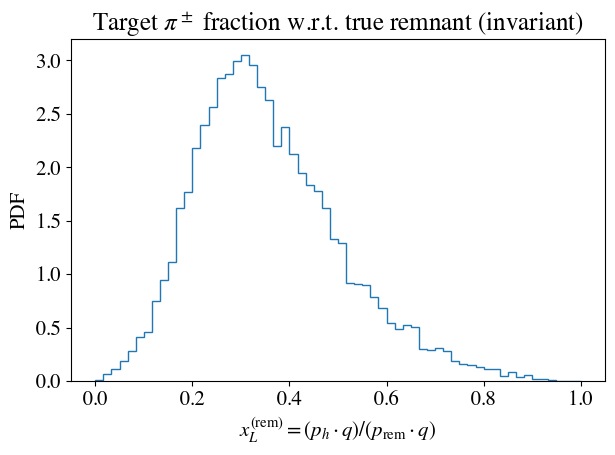

In [10]:
import pythia8
import numpy as np
import matplotlib.pyplot as plt

# ---------- helpers ----------
def is_hadron(pid):
    return abs(pid) >= 100

def p3(v):  # v=(E,px,py,pz)
    return np.array([v[1], v[2], v[3]], dtype=float)

def pT_rel_to_axis(p_vec, axis_vec):
    na = np.linalg.norm(axis_vec)
    if na <= 0:
        return None
    n = axis_vec / na
    p_par = np.dot(p_vec, n) * n
    p_perp = p_vec - p_par
    return float(np.linalg.norm(p_perp))

def dot4(a, b):  # Minkowski (+,-,-,-)
    return a[0]*b[0] - a[1]*b[1] - a[2]*b[2] - a[3]*b[3]

def p4(p):  # Pythia particle -> numpy 4-vector
    return np.array([p.e(), p.px(), p.py(), p.pz()], dtype=float)


# ================== Pythia setup ==================
pythia = pythia8.Pythia()

Ee_set = 18.0
Ep_set = 275.0

pythia.readString("Beams:idA = 2212")
pythia.readString("Beams:idB = 11")
pythia.readString(f"Beams:eA = {Ep_set}")
pythia.readString(f"Beams:eB = {Ee_set}")
pythia.readString("Beams:frameType = 2")

pythia.readString("WeakBosonExchange:ff2ff(t:gmZ) = on")
pythia.readString("HardQCD:all = off")

pythia.readString("PDF:lepton = off")
pythia.readString("PartonLevel:ISR = off")
pythia.readString("PartonLevel:FSR = off")
pythia.readString("HadronLevel:all = on")
pythia.readString("ColourReconnection:reconnect = off")

pythia.readString("PhaseSpace:Q2Min = 16.0")
pythia.init()


# ---------------- Analysis cuts ----------------
Qmin, Qmax = 5.0, 15.0
xmin, xmax = 1e-3, 0.5
n_events = 100_000

# ---------------- Outputs ----------------
# pT of leading target pion relative to REMNANT axis (hadron-level, Breit)
pTrel_to_remnant_list = []

# your invariant xL with respect to true remnant (same as before)
xL_remnant_list = []

# Track x and Q for events that are kept
x_list = []
Q_list = []

# Diagnostics
n_pass_evt = 0
n_boost = 0
n_have_target_pion = 0
printed_first_event = False  # Flag to print diagnostics once
printed_first_passing_event = False  # Flag to print momenta for first passing event

# Additional diagnostics to track where events are filtered
n_total_events = 0
n_no_pythia_next = 0
n_missing_particles = 0
n_Q2_negative = 0
n_p_dot_q_zero = 0
n_fail_x_cut = 0
n_fail_Q_cut = 0
n_fail_denom_M1 = 0
n_fail_den2 = 0
n_fail_num_log = 0
n_fail_den_log = 0
n_fail_denom_M4 = 0


# ================= EVENT LOOP =================
print(f"Processing {n_events} events...")
for iEvent in range(n_events):
    n_total_events += 1
    
    # Progress indicator every 10% or every 10000 events
    if iEvent > 0 and (iEvent % max(1, n_events // 10) == 0 or iEvent % 10000 == 0):
        print(f"  Processed {iEvent}/{n_events} events ({iEvent/n_events*100:.1f}%) - "
              f"Passed x-Q: {n_pass_evt}, Valid boost: {n_boost}, Target pion: {n_have_target_pion}")

    if not pythia.next():
        n_no_pythia_next += 1
        continue

    ev = pythia.event

    # Identify incoming e, scattered e, proton
    # When ISR/FSR are off, status codes may differ
    e_in = e_sc = p_in = None
    electrons = []  # Collect all electrons to find scattered one
    
    for p in ev:
        pid = p.id()
        status = p.status()
        # Incoming electron: status -12 (incoming beam)
        if pid == 11 and status == -12:
            e_in = p
        # Collect all final/intermediate electrons (for scattered electron identification)
        elif pid == 11 and status > 0:
            electrons.append(p)
        # Incoming proton: status < 0 (incoming)
        elif pid == 2212 and status < 0:
            p_in = p
    
    # Find scattered electron: prefer status 44, otherwise take any electron that's not incoming
    if e_in is not None and electrons:
        for e in electrons:
            if e.status() == 44:  # Preferred: hard process final
                e_sc = e
                break
        # If no status 44 found, take the first electron (when ISR/FSR off, might be status 23 or other)
        if e_sc is None:
            e_sc = electrons[0]

    if not (e_in and e_sc and p_in):
        n_missing_particles += 1
        # Diagnostic: print first few events to see what particles exist
        if n_missing_particles <= 3:
            print(f"\nEvent {iEvent} - Missing particles:")
            print(f"  e_in: {e_in is not None}, e_sc: {e_sc is not None}, p_in: {p_in is not None}")
            # Count particles in event
            event_size = 0
            particles_info = []
            for p in ev:
                event_size += 1
                if event_size <= 10:  # Store first 10 particles
                    particles_info.append((p.id(), p.status(), pythia.particleData.name(p.id())))
            print(f"  Event size: {event_size}")
            print("  Particles in event (first 10):")
            for i, (pid, status, name) in enumerate(particles_info):
                print(f"    [{i}] id={pid}, status={status}, name={name}")
        continue

    Ee, Ep = e_in.e(), p_in.e()

    # Virtual photon
    q0 = e_in.e()  - e_sc.e()
    q1 = e_in.px() - e_sc.px()
    q2 = e_in.py() - e_sc.py()
    q3 = e_in.pz() - e_sc.pz()
    qmu = np.array([q0, q1, q2, q3], dtype=float)

    # Invariants
    Q2 = -(q0*q0 - q1*q1 - q2*q2 - q3*q3)
    if Q2 <= 0:
        n_Q2_negative += 1
        continue
    Q = float(np.sqrt(Q2))
    qT = float(np.hypot(q1, q2))

    p_dot_q = Ep*q0 - Ep*q3
    if p_dot_q == 0:
        n_p_dot_q_zero += 1
        continue

    x = Q2 / (2.0 * p_dot_q)
    if not (xmin <= x <= xmax):
        n_fail_x_cut += 1
        continue
    if not (Qmin <= Q <= Qmax):
        n_fail_Q_cut += 1
        continue

    n_pass_evt += 1

    # Orientation angle for qT rotation
    phiq = float(np.arctan2(q2, q1))
    S = 4.0 * Ee * Ep
    y = Q2 / (S * x)  # inelasticity

    # ---------------- Build your Breit transform ----------------
    Mm1 = np.array([
        [Ee/np.sqrt(S) + np.sqrt(S)/(4.0*Ee), 0,0, Ee/np.sqrt(S) - np.sqrt(S)/(4.0*Ee)],
        [0,1,0,0],
        [0,0,1,0],
        [Ee/np.sqrt(S) - np.sqrt(S)/(4.0*Ee), 0,0, Ee/np.sqrt(S) + np.sqrt(S)/(4.0*Ee)]
    ])

    M0 = np.array([
        [1,0,0,0],
        [0, np.cos(phiq), np.sin(phiq), 0],
        [0,-np.sin(phiq), np.cos(phiq), 0],
        [0,0,0,1]
    ])

    # M1 matrix: matches Mathematica expression exactly
    # denom = 2*y*sqrt(S*(S*(x+1)*y - qT^2))
    denom_M1 = 2.0 * y * np.sqrt(S * (S*(1+x)*y - qT*qT))
    if denom_M1 == 0:
        n_fail_denom_M1 += 1
        continue

    M1 = np.array([
        [(S*y*(x+y+1) - qT*qT) / denom_M1, 0,0,
         (qT*qT + S*y*(-x+y-1)) / denom_M1],
        [0,1,0,0],
        [0,0,1,0],
        [(qT*qT + S*y*(-x+y-1)) / denom_M1, 0,0,
         (S*y*(x+y+1) - qT*qT) / denom_M1]
    ])

    # M2 matrix: matches Mathematica expression exactly
    # den2 = S*(x+1)*y - qT^2
    den2 = S*(1+x)*y - qT*qT
    if den2 <= 0:
        n_fail_den2 += 1
        continue

    # M2[1,1] = 1/sqrt(S*(x+1)*y / (S*(x+1)*y - qT^2))
    denom_M2_s1 = np.sqrt(S*(1+x)*y / den2)
    # M2[1,3] = qT/sqrt(S*(x+1)*y)
    denom_M2_s2 = np.sqrt(S*(1+x)*y)

    M2 = np.array([
        [1,0,0,0],
        [0,1/denom_M2_s1,0, qT/denom_M2_s2],
        [0,0,1,0],
        [0,-qT/denom_M2_s2,0,1/denom_M2_s1]
    ])

    # M3 matrix: matches Mathematica expression exactly
    # M3[0,0] = cosh(0.5*log((qT + sqrt(S*(x+1)*y)) / (sqrt(S*(x+1)*y) - qT)))
    # M3[0,1] = -qT/sqrt(S*(x+1)*y - qT^2)
    denom_M3 = np.sqrt(den2)  # sqrt(S*(x+1)*y - qT^2)
    num_log = qT + np.sqrt(S*(1+x)*y)
    den_log = np.sqrt(S*(1+x)*y) - qT
    if num_log <= 0:
        n_fail_num_log += 1
        continue
    if den_log <= 0:
        n_fail_den_log += 1
        continue

    eta = 0.5*np.log(num_log/den_log)
    M3 = np.array([
        [np.cosh(eta), -qT/denom_M3, 0,0],
        [-qT/denom_M3, np.cosh(eta), 0,0],
        [0,0,1,0],
        [0,0,0,1]
    ])

    denom_M4 = 2*np.sqrt(x*(1+x))
    if denom_M4 == 0:
        n_fail_denom_M4 += 1
        continue

    M4 = np.array([
        [(1+2*x)/denom_M4, 0,0, 1/denom_M4],
        [0,1,0,0],
        [0,0,1,0],
        [1/denom_M4, 0,0,(1+2*x)/denom_M4]
    ])

    # ---------------- Print diagnostics for first event ----------------
    if not printed_first_event:
        printed_first_event = True
        print("=" * 70)
        print("KINEMATIC VARIABLES (before boosts)")
        print("=" * 70)
        print(f"x  = {x:.10f}")
        print(f"y  = {y:.10f}")
        print(f"Q  = {Q:.10f} GeV")
        print(f"qT = {qT:.10f} GeV")
        print(f"phi = {phiq:.10f} radians")
        print(f"S  = {S:.10f} GeV²")
        print(f"Ei = Ee = {Ee:.10f} GeV")
        print(f"Ep = {Ep:.10f} GeV")
        print("=" * 70)
        print("\nMATRICES (for comparison with Mathematica):")
        print("\nMm1 =")
        print(Mm1)
        print("\nM0 =")
        print(M0)
        print("\nM1 =")
        print(M1)
        print("\nM2 =")
        print(M2)
        print("\nM3 =")
        print(M3)
        print("\nM4 =")
        print(M4)
        print()

    # Try both orders - Mathematica might apply in reverse order
    # Standard order: M4 @ M3 @ M2 @ M1 @ M0 @ Mm1
    # Reverse order: Mm1 @ M0 @ M1 @ M2 @ M3 @ M4
    LT = M4 @ M3 @ M2 @ M1 @ M0 @ Mm1
    # If this doesn't work, try: LT = Mm1 @ M0 @ M1 @ M2 @ M3 @ M4

    def boost(v): 
        return LT @ np.array(v)

    n_boost += 1

    # ---------------- Verify Breit frame transformation ----------------
    # Boost photon and proton to Breit frame
    q_breit = boost(qmu)
    p_breit = boost([p_in.e(), p_in.px(), p_in.py(), p_in.pz()])
    
    # Print for first few events to verify
    if n_boost <= 10:
        print(f"\n=== Event {n_boost} ===")
        print(f"Lab frame - Q = {Q:.4f} GeV, x = {x:.4f}, qT = {qT:.4f} GeV")
        print(f"Photon (lab):     E={q0:8.4f}, px={q1:8.4f}, py={q2:8.4f}, pz={q3:8.4f}")
        print(f"Photon (Breit):   E={q_breit[0]:8.4f}, px={q_breit[1]:8.4f}, py={q_breit[2]:8.4f}, pz={q_breit[3]:8.4f}")
        print(f"  |q_Breit| = {np.sqrt(q_breit[1]**2 + q_breit[2]**2 + q_breit[3]**2):.4f} GeV (should be close to Q={Q:.4f})")
        print(f"Proton (lab):     E={p_in.e():8.4f}, px={p_in.px():8.4f}, py={p_in.py():8.4f}, pz={p_in.pz():8.4f}")
        print(f"Proton (Breit):   E={p_breit[0]:8.4f}, px={p_breit[1]:8.4f}, py={p_breit[2]:8.4f}, pz={p_breit[3]:8.4f}")
        print(f"  P+ (Breit) = {p_breit[0] + p_breit[3]:.4f} GeV")

    # ---------------- Proton in Breit (for xL_Breit) ----------------
    P_breit = boost([p_in.e(), p_in.px(), p_in.py(), p_in.pz()])
    P_plus = float(P_breit[0] + P_breit[3])
    if P_plus <= 0:
        continue

    # ---------------- Target region: most energetic hadron must be pi+ or pi- (Breit) ----------------
    best_tarE = -1.0
    best_tar_breit = None
    best_tar_pid = None

    for p in ev:
        if not p.isFinal():
            continue
        if not is_hadron(p.id()):
            continue

        lab = np.array([p.e(), p.px(), p.py(), p.pz()])
        trf = boost(lab)
        E_, px_, py_, pz_ = trf

        if pz_ <= 0:
            continue  # target hemisphere

        if E_ > best_tarE:
            best_tarE = E_
            best_tar_breit = trf
            best_tar_pid = p.id()

    if best_tar_breit is None:
        continue

    # require the most energetic TARGET hadron is pi+ or pi-
    if abs(best_tar_pid) != 211:
        continue
    n_have_target_pion += 1

    # boost q into Breit so dot-products are consistent
    q_breit = boost([q0, q1, q2, q3])

    # ---------------- Find struck quark using Pythia hard process information ----------------
    # Find outgoing hard quark (truth)
    # In Pythia8, hard process quarks typically have status 23 (hard process intermediate)
    # or status 63-68 (hard process final)
    k_out = None
    
    # First try: look for quarks with status 23 (hard process intermediate)
    for pp in ev:
        pid = pp.id()
        status = abs(pp.status())
        if 1 <= abs(pid) <= 6 and status == 23:  # quark with hard process status
            k_out = p4(pp)
            break
    
    # Second try: look for quarks with status 63-68 (hard process final)
    if k_out is None:
        for pp in ev:
            pid = pp.id()
            status = abs(pp.status())
            if 1 <= abs(pid) <= 6 and 63 <= status <= 68:  # quark with hard process final status
                k_out = p4(pp)
                break
    
    # Third try: look for any quark with positive status (not incoming)
    if k_out is None:
        for pp in ev:
            pid = pp.id()
            status = pp.status()
            if 1 <= abs(pid) <= 6 and status > 0:  # any outgoing quark
                k_out = p4(pp)
                break

    if k_out is None:
        # couldn't identify the outgoing hard quark in this event
        continue

    k_in = k_out - qmu                 # incoming struck parton (truth)
    p_rem_truth = p4(p_in) - k_in      # proton remnant before hadronization

    # ---------------- True remnant momentum (sum over target hemisphere final state) ----------------
    p_rem = np.zeros(4)
    for pp in ev:
        if not pp.isFinal():
            continue
        lab_pp = np.array([pp.e(), pp.px(), pp.py(), pp.pz()])
        trf = boost(lab_pp)
        if trf[3] > 0:   # target hemisphere
            p_rem += trf

    # Boost truth-level momenta to Breit frame
    p_proton_breit = boost([p_in.e(), p_in.px(), p_in.py(), p_in.pz()])
    k_in_breit = boost(k_in)
    k_out_breit = boost(k_out)
    p_rem_truth_breit = boost(p_rem_truth)

    # ---------------- Print momenta for first passing event ----------------
    if not printed_first_passing_event:
        printed_first_passing_event = True
        print("\n" + "=" * 70)
        print("MOMENTA FOR FIRST PASSING EVENT (Breit Frame)")
        print("=" * 70)
        print(f"\nPhoton momentum (q_breit):")
        print(f"  E  = {q_breit[0]:12.6f} GeV")
        print(f"  px = {q_breit[1]:12.6f} GeV")
        print(f"  py = {q_breit[2]:12.6f} GeV")
        print(f"  pz = {q_breit[3]:12.6f} GeV")
        print(f"  |q| = {np.sqrt(q_breit[1]**2 + q_breit[2]**2 + q_breit[3]**2):12.6f} GeV (should be close to Q={Q:.6f} GeV)")
        print(f"\nStruck quark momentum (from Pythia hard process):")
        print(f"  Incoming struck quark (k_in) in Breit frame:")
        print(f"    E  = {k_in_breit[0]:12.6f} GeV")
        print(f"    px = {k_in_breit[1]:12.6f} GeV")
        print(f"    py = {k_in_breit[2]:12.6f} GeV")
        print(f"    pz = {k_in_breit[3]:12.6f} GeV")
        print(f"    |p| = {np.sqrt(k_in_breit[1]**2 + k_in_breit[2]**2 + k_in_breit[3]**2):12.6f} GeV")
        print(f"  Outgoing quark (k_out) in Breit frame:")
        print(f"    E  = {k_out_breit[0]:12.6f} GeV")
        print(f"    px = {k_out_breit[1]:12.6f} GeV")
        print(f"    py = {k_out_breit[2]:12.6f} GeV")
        print(f"    pz = {k_out_breit[3]:12.6f} GeV")
        print(f"    |p| = {np.sqrt(k_out_breit[1]**2 + k_out_breit[2]**2 + k_out_breit[3]**2):12.6f} GeV")
        print(f"\nProton remnant momentum:")
        print(f"  Truth-level remnant (p_rem_truth) in Breit frame:")
        print(f"    E  = {p_rem_truth_breit[0]:12.6f} GeV")
        print(f"    px = {p_rem_truth_breit[1]:12.6f} GeV")
        print(f"    py = {p_rem_truth_breit[2]:12.6f} GeV")
        print(f"    pz = {p_rem_truth_breit[3]:12.6f} GeV")
        print(f"    |p| = {np.sqrt(p_rem_truth_breit[1]**2 + p_rem_truth_breit[2]**2 + p_rem_truth_breit[3]**2):12.6f} GeV")
        print(f"  Hadron-level remnant (p_rem) in Breit frame:")
        print(f"    E  = {p_rem[0]:12.6f} GeV")
        print(f"    px = {p_rem[1]:12.6f} GeV")
        print(f"    py = {p_rem[2]:12.6f} GeV")
        print(f"    pz = {p_rem[3]:12.6f} GeV")
        print(f"    |p| = {np.sqrt(p_rem[1]**2 + p_rem[2]**2 + p_rem[3]**2):12.6f} GeV")
        print(f"\nProton momentum in Breit frame (for reference):")
        print(f"  E  = {p_proton_breit[0]:12.6f} GeV")
        print(f"  px = {p_proton_breit[1]:12.6f} GeV")
        print(f"  py = {p_proton_breit[2]:12.6f} GeV")
        print(f"  pz = {p_proton_breit[3]:12.6f} GeV")
        print(f"  P+ = {p_proton_breit[0] + p_proton_breit[3]:12.6f} GeV")
        print(f"\nTarget-leading pion momentum (best_tar_breit):")
        print(f"  E  = {best_tar_breit[0]:12.6f} GeV")
        print(f"  px = {best_tar_breit[1]:12.6f} GeV")
        print(f"  py = {best_tar_breit[2]:12.6f} GeV")
        print(f"  pz = {best_tar_breit[3]:12.6f} GeV")
        print(f"  |p| = {np.sqrt(best_tar_breit[1]**2 + best_tar_breit[2]**2 + best_tar_breit[3]**2):12.6f} GeV")
        print(f"  PID = {best_tar_pid}")
        print("=" * 70)
        print()

    # ---------------- pTrel of leading target pion w.r.t. remnant axis ----------------
    # Use truth-level remnant momentum (before hadronization) as axis
    axis_rem = p3(p_rem_truth_breit)
    if np.linalg.norm(axis_rem) <= 0:
        continue

    pTrel_rem = pT_rel_to_axis(p3(best_tar_breit), axis_rem)
    if pTrel_rem is None:
        continue

    # ---------------- invariant xL (using truth-level remnant) ----------------
    den = dot4(p_rem_truth_breit, q_breit)
    if den <= 0:
        continue

    xL_exact = dot4(best_tar_breit, q_breit) / den
    if xL_exact < 0.01 or xL_exact > 1.0 + 1e-6:
        continue

    pTrel_to_remnant_list.append(pTrel_rem)
    xL_remnant_list.append(xL_exact)
    
    # Track x and Q for this event
    x_list.append(x)
    Q_list.append(Q)


# ================= PLOTS =================
plt.figure()

counts, edges = np.histogram(
    pTrel_to_remnant_list,
    bins=60,
    range=(0.2, 5),   # avoid pT = 0
    density=True
)

centers = 0.5 * (edges[:-1] + edges[1:])
binw = edges[1:] - edges[:-1]

# Convert to 2D density: d²σ/d²p_T = (1/p_T) dσ/dp_T
# where dσ/dp_T is the 1D density from histogram (normalized to 1 by density=True)
y2d = counts / centers  # This gives d²σ/d²p_T

# Check normalization
# 1D normalization: ∫ dp_T (dσ/dp_T) should be ≈ 1.0 (from density=True)
norm_1d = np.sum(counts * binw)
print(f"\nNormalization check:")
print(f"  1D normalization: ∫ dp_T (dσ/dp_T) = {norm_1d:.6f} (should be ≈ 1.0)")

# 2D normalization: ∫ d²p_T d²σ/d²p_T = ∫ dp_T (2π p_T) d²σ/d²p_T
#                   = 2π ∫ dp_T p_T (1/p_T) dσ/dp_T
#                   = 2π ∫ dp_T dσ/dp_T = 2π
norm_2d = 2.0 * np.pi * np.sum(centers * binw * y2d)
print(f"  2D normalization: 2π ∫ dp_T p_T (d²σ/d²p_T) = {norm_2d:.6f} (should be ≈ 2π ≈ {2*np.pi:.6f})")

# Verify: ∫ d²p_T d²σ/d²p_T = ∫ dp_T (2π p_T) y2d should equal 2π
print(f"  Verification: ∫ d²p_T d²σ/d²p_T = {norm_2d:.6f} (should equal 2π)")

plt.step(centers, y2d, where="mid")

plt.xlabel(r"$p_{T,\mathrm{rel}}^{\mathrm{Breit}}$")
plt.ylabel(r"$d^2\sigma/d^2\vec p_T$")
plt.title(r"Target-leading $\pi^\pm$: 2D transverse-momentum density")
plt.tight_layout()
plt.savefig("pTrel_target_pion_wrt_remnant_axis_2D.png", dpi=180)

plt.figure()
plt.hist(xL_remnant_list, bins=60, range=(0,1), histtype="step", density=True)
plt.xlabel(r"$x_L^{\mathrm{(rem)}} = (p_h\cdot q)/(p_{\rm rem}\cdot q)$")
plt.ylabel("PDF")
plt.title(r"Target $\pi^\pm$ fraction w.r.t. true remnant (invariant)")
plt.tight_layout()
plt.savefig("xL_target_pion_remnant_invariant.png", dpi=180)

print("\nSummary:")
print(f"Total events processed:       {n_total_events}")
print(f"Events passing (x,Q):        {n_pass_evt}")
print(f"Events w/ target-leading pion: {n_have_target_pion}")
print(f"Events kept (filled observables): {len(pTrel_to_remnant_list)}")
if len(x_list) > 0:
    print(f"Average x:                    {np.mean(x_list):.6f}")
    print(f"Average Q:                    {np.mean(Q_list):.6f} GeV")
print("\nDiagnostics - Events filtered BEFORE x-Q cuts:")
print(f"  Failed pythia.next():      {n_no_pythia_next}")
print(f"  Missing particles:          {n_missing_particles}")
print(f"  Q2 <= 0:                    {n_Q2_negative}")
print(f"  p_dot_q == 0:               {n_p_dot_q_zero}")
print(f"  Failed x cut ({xmin} <= x <= {xmax}): {n_fail_x_cut}")
print(f"  Failed Q cut ({Qmin} <= Q <= {Qmax}): {n_fail_Q_cut}")
print("\nDiagnostics - Events filtered AFTER x-Q cuts:")
print(f"  Failed denom_M1 check:     {n_fail_denom_M1}")
print(f"  Failed den2 <= 0 check:    {n_fail_den2}")
print(f"  Failed num_log <= 0:       {n_fail_num_log}")
print(f"  Failed den_log <= 0:       {n_fail_den_log}")
print(f"  Failed denom_M4 == 0:      {n_fail_denom_M4}")
print(f"  Total filtered after x-Q:  {n_fail_denom_M1 + n_fail_den2 + n_fail_num_log + n_fail_den_log + n_fail_denom_M4}")
print(f"  Events with valid boost:   {n_boost}")
if n_pass_evt > 0:
    print(f"  Efficiency:                {n_boost/n_pass_evt*100:.2f}%")
else:
    print(f"  Efficiency:                N/A (no events passed x-Q cuts)")



Normalization check:
  1D normalization: ∫ dp_T (dσ/dp_T) = 1.000000 (should be ≈ 1.0)
  2D normalization: 2π ∫ dp_T p_T (d²σ/d²p_T) = 6.283185 (should be ≈ 2π ≈ 6.283185)
  Verification: ∫ d²p_T d²σ/d²p_T = 6.283185 (should equal 2π)


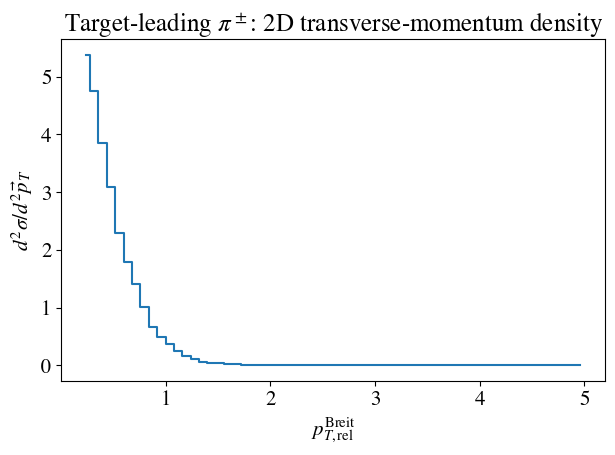

In [11]:
plt.figure()

counts, edges = np.histogram(
    pTrel_to_remnant_list,
    bins=60,
    range=(0.2, 5),   # avoid pT = 0
    density=True
)

centers = 0.5 * (edges[:-1] + edges[1:])
binw = edges[1:] - edges[:-1]

# Convert to 2D density: d²σ/d²p_T = (1/p_T) dσ/dp_T
# where dσ/dp_T is the 1D density from histogram (normalized to 1 by density=True)
y2d = counts / centers  # This gives d²σ/d²p_T

# Check normalization
# 1D normalization: ∫ dp_T (dσ/dp_T) should be ≈ 1.0 (from density=True)
norm_1d = np.sum(counts * binw)
print(f"\nNormalization check:")
print(f"  1D normalization: ∫ dp_T (dσ/dp_T) = {norm_1d:.6f} (should be ≈ 1.0)")

# 2D normalization: ∫ d²p_T d²σ/d²p_T = ∫ dp_T (2π p_T) d²σ/d²p_T
#                   = 2π ∫ dp_T p_T (1/p_T) dσ/dp_T
#                   = 2π ∫ dp_T dσ/dp_T = 2π
norm_2d = 2.0 * np.pi * np.sum(centers * binw * y2d)
print(f"  2D normalization: 2π ∫ dp_T p_T (d²σ/d²p_T) = {norm_2d:.6f} (should be ≈ 2π ≈ {2*np.pi:.6f})")

# Verify: ∫ d²p_T d²σ/d²p_T = ∫ dp_T (2π p_T) y2d should equal 2π
print(f"  Verification: ∫ d²p_T d²σ/d²p_T = {norm_2d:.6f} (should equal 2π)")

plt.step(centers, y2d, where="mid")

plt.xlabel(r"$p_{T,\mathrm{rel}}^{\mathrm{Breit}}$")
plt.ylabel(r"$d^2\sigma/d^2\vec p_T$")
plt.title(r"Target-leading $\pi^\pm$: 2D transverse-momentum density")
plt.tight_layout()
plt.savefig("pTrel_target_pion_wrt_remnant_axis_2D.png", dpi=180)


In [12]:
plt.figure()
plt.hist(xL_breit_list, bins=40, range=(0,1), histtype="step", density=True)
plt.xlabel(r"$x_L^{\mathrm{Breit}} = p_h^+/P^+$")
plt.ylabel("PDF")
plt.title(r"Target $\pi^\pm$ plus-fraction w.r.t proton (Breit)")
plt.tight_layout()
plt.savefig("xL_target_pion_Breit.png", dpi=180)

NameError: name 'xL_breit_list' is not defined

<Figure size 640x480 with 0 Axes>


Gaussian fit to 2D density for pT < 1.00 GeV (single width parameter):
B  = 0.34649510013187085   (so width sqrt(<pT^2>) = sqrt(B) = 0.5886383440890263 )
A  = 5.7738204795466   (determined from normalization)


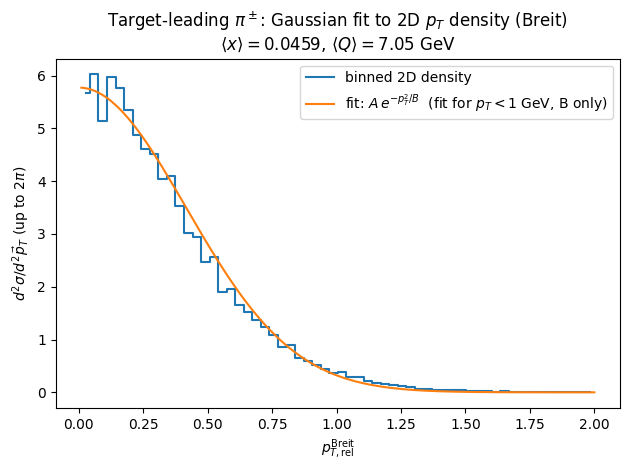

In [ ]:
# ================= Fit d^2σ/d^2pT with a Gaussian for pT < 2 GeV =================
pTmax_fit = 1.0
eps = 1e-12  # guard against log(0)

# histogram for dσ/dpT (density=True gives normalized 1D pdf in pT)
counts, edges = np.histogram(
    pTrel_to_remnant_list,
    bins=60,
    range=(0.01, 2.0),
    density=True
)
centers = 0.5 * (edges[:-1] + edges[1:])
binw = edges[1:] - edges[:-1]

# Convert to 2D density up to an overall (2π) factor:
# d^2σ/d^2pT ∝ (1/pT) dσ/dpT  --> y = counts / centers
y2d = counts / centers

# Statistical uncertainty estimate (optional but helpful):
# For N events, expected count in bin i ~ N * pdf_i * Δp
# So σ(pdf_i) ~ sqrt(n_i)/(N*Δp). Here we estimate n_i from pdf_i.
N = len(pTrel_to_remnant_list)
n_i_est = np.maximum(N * counts * binw, 1.0)  # avoid zeros
sigma_counts = np.sqrt(n_i_est) / (N * binw)  # σ on counts (pdf)
sigma_y2d = sigma_counts / centers            # propagate to y2d

# Fit region mask
mask = (centers < pTmax_fit) & (y2d > 0) & np.isfinite(y2d) & np.isfinite(sigma_y2d)

# Fit with single width parameter B only (no normalization A)
# Model: y = A * exp(-p_T^2 / B) where A is determined by normalization
# We fit only B, then determine A from the normalization constraint

# Fit in log-space: ln y = lnA - pT^2 / B
# For fixed normalization, we fit only the slope (B), not the intercept (A)
X = centers[mask]**2
Y = np.log(y2d[mask] + eps)

# weights for log fit: σ(ln y) ≈ σ_y / y
sigma_lnY = sigma_y2d[mask] / (y2d[mask] + eps)
w = 1.0 / np.maximum(sigma_lnY, 1e-6)**2

# Fit only the slope (c1 = -1/B), removing normalization dependence
# We center the data to remove the intercept term
Y_mean = np.average(Y, weights=w)
Y_centered = Y - Y_mean
X_mean = np.average(X, weights=w)
X_centered = X - X_mean

# Weighted linear regression for slope only: Y_centered = c1 * X_centered
# c1 = Σ(w * X_centered * Y_centered) / Σ(w * X_centered^2)
numerator = np.sum(w * X_centered * Y_centered)
denominator = np.sum(w * X_centered**2)
c1 = numerator / denominator if denominator > 0 else 0.0

# Map to width parameter: c1 = -1/B
B_fit = float(-1.0 / c1) if c1 < 0 else 1.0

# Determine A from normalization constraint
# For normalized 2D distribution: 2π ∫ dp_T p_T A exp(-p_T^2/B) = 2π
# This gives: A = 2/B
# But to match the actual data normalization, we compute A numerically
p_integrate = np.linspace(0.01, 2.0, 1000)
integrand = p_integrate * np.exp(-(p_integrate**2) / B_fit)
integral = np.trapz(integrand, p_integrate)
A_fit = 1.0 / integral if integral > 0 else 1.0

print("\nGaussian fit to 2D density for pT < %.2f GeV (single width parameter):" % pTmax_fit)
print("B  =", B_fit, "  (so width sqrt(<pT^2>) = sqrt(B) =", np.sqrt(B_fit), ")")
print("A  =", A_fit, "  (determined from normalization)")

# Calculate average x and Q for the plot title
avg_x = np.mean(x_list) if len(x_list) > 0 else 0.0
avg_Q = np.mean(Q_list) if len(Q_list) > 0 else 0.0

# Overlay plot
plt.figure()
plt.step(centers, y2d, where="mid", label="binned 2D density")

p_grid = np.linspace(0.01, 2.0, 200)
y_fit = A_fit * np.exp(-(p_grid**2) / B_fit)
plt.plot(p_grid, y_fit, label=r"fit: $A\,e^{-p_T^2/B}$  (fit for $p_T<1$ GeV, B only)")

plt.xlabel(r"$p_{T,\mathrm{rel}}^{\mathrm{Breit}}$")
plt.ylabel(r"$d^2\sigma/d^2\vec p_T$ (up to $2\pi$)")
plt.title(r"Target-leading $\pi^\pm$: Gaussian fit to 2D $p_T$ density (Breit)" + 
          f"\n$\\langle x \\rangle = {avg_x:.4f}$, $\\langle Q \\rangle = {avg_Q:.2f}$ GeV")
plt.legend()
plt.tight_layout()
plt.savefig("pTrel_target_pion_wrt_remnant_axis_2D_fit_gaussian.png", dpi=180)


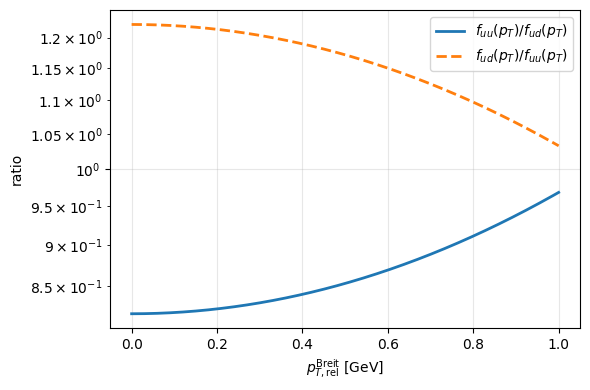

At pT = 0:
f_uu / f_ud = 0.8181818181818182
f_ud / f_uu = 1.222222222222222


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- widths (stronger ud correlation -> smaller width) ---
sigma2_ud = 0.9*1.2   # GeV^2  (stronger correlation)
sigma2_uu = 1.1*1.2   # GeV^2  (weaker correlation)

# pT grid
pT = np.linspace(0.0, 1.0, 600)

# normalized 2D Gaussians
f_ud = np.exp(-pT**2 / sigma2_ud) / (np.pi * sigma2_ud)
f_uu = np.exp(-pT**2 / sigma2_uu) / (np.pi * sigma2_uu)

# ratios
R_uu_over_ud = f_uu / f_ud
R_ud_over_uu = f_ud / f_uu

plt.figure(figsize=(6,4))
plt.plot(pT, R_uu_over_ud, linewidth=2,
         label=r"$f_{uu}(p_T)/f_{ud}(p_T)$")
plt.plot(pT, R_ud_over_uu, linewidth=2, linestyle="--",
         label=r"$f_{ud}(p_T)/f_{uu}(p_T)$")

plt.xlabel(r"$p_{T,\mathrm{rel}}^{\mathrm{Breit}}~[\mathrm{GeV}]$")
plt.ylabel(r"ratio")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("pTrel_model_ratio_uu_ud.png", dpi=180)
plt.show()

print("At pT = 0:")
print("f_uu / f_ud =", sigma2_ud / sigma2_uu)
print("f_ud / f_uu =", sigma2_uu / sigma2_ud)


✓ Both datasets available - creating comparison fit plot...

Gaussian fit results:
ISR/FSR OFF: B = 0.346495, A = 5.773820, N = 15432
ISR/FSR ON:  B = 0.442272, A = 4.523666, N = 17407
✓ Saved comparison plot: pTrel_target_pion_wrt_remnant_axis_2D_fit_gaussian_comparison.pdf


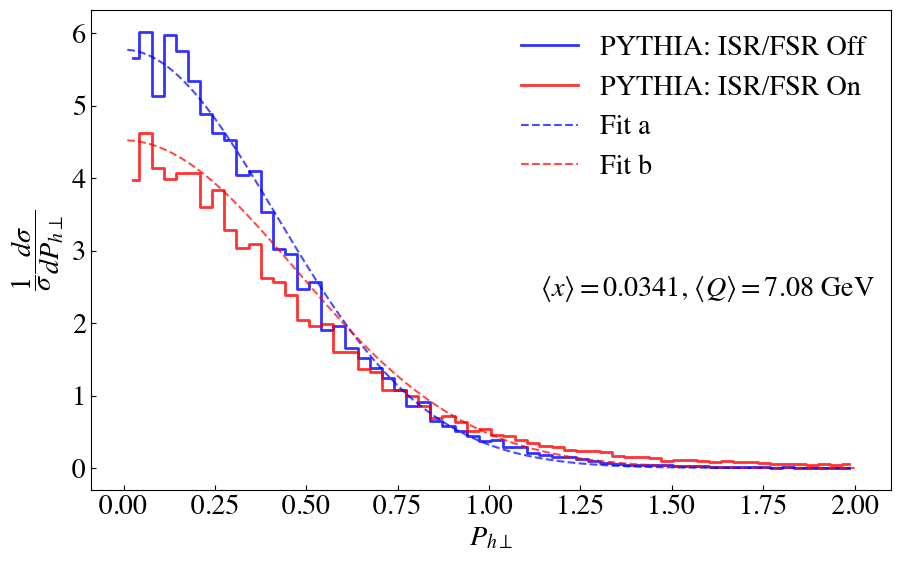

In [28]:
# ================= Comparison: Gaussian fit for ISR/FSR OFF and ON =================
pTmax_fit = 1.0
eps = 1e-12  # guard against log(0)

# Check if both datasets exist
has_off = 'pTrel_to_remnant_list' in locals() or 'pTrel_to_remnant_list' in globals()
has_on = 'pTrel_to_remnant_list_on' in locals() or 'pTrel_to_remnant_list_on' in globals()

if not (has_off and has_on):
    print("⚠ Need both pTrel_to_remnant_list (ISR/FSR OFF) and pTrel_to_remnant_list_on (ISR/FSR ON)")
    print(f"  Available: OFF={has_off}, ON={has_on}")
else:
    print("✓ Both datasets available - creating comparison fit plot...")
    
    # Function to perform fit on a dataset
    def fit_gaussian_single_width(pT_list, label_suffix=""):
        """Fit Gaussian with single width parameter B, return fit params and histogram data"""
        if len(pT_list) == 0:
            return None, None, None, None, None, None
        
        # histogram for dσ/dpT (density=True gives normalized 1D pdf in pT)
        counts, edges = np.histogram(
            pT_list,
            bins=60,
            range=(0.01, 2.0),
            density=True
        )
        centers = 0.5 * (edges[:-1] + edges[1:])
        binw = edges[1:] - edges[:-1]
        
        # Convert to 2D density: d^2σ/d^2pT ∝ (1/pT) dσ/dpT
        y2d = counts / centers
        
        # Statistical uncertainty estimate
        N = len(pT_list)
        n_i_est = np.maximum(N * counts * binw, 1.0)
        sigma_counts = np.sqrt(n_i_est) / (N * binw)
        sigma_y2d = sigma_counts / centers
        
        # Fit region mask
        mask = (centers < pTmax_fit) & (y2d > 0) & np.isfinite(y2d) & np.isfinite(sigma_y2d)
        
        if np.sum(mask) < 3:  # Need at least 3 points for fit
            return None, None, None, None, None, None
        
        # Fit in log-space: ln y = lnA - pT^2 / B
        X = centers[mask]**2
        Y = np.log(y2d[mask] + eps)
        
        # weights for log fit
        sigma_lnY = sigma_y2d[mask] / (y2d[mask] + eps)
        w = 1.0 / np.maximum(sigma_lnY, 1e-6)**2
        
        # Fit only the slope (c1 = -1/B), removing normalization dependence
        Y_mean = np.average(Y, weights=w)
        Y_centered = Y - Y_mean
        X_mean = np.average(X, weights=w)
        X_centered = X - X_mean
        
        # Weighted linear regression for slope only
        numerator = np.sum(w * X_centered * Y_centered)
        denominator = np.sum(w * X_centered**2)
        c1 = numerator / denominator if denominator > 0 else 0.0
        
        # Map to width parameter: c1 = -1/B
        B_fit = float(-1.0 / c1) if c1 < 0 else 1.0
        
        # Determine A from normalization constraint
        p_integrate = np.linspace(0.01, 2.0, 1000)
        integrand = p_integrate * np.exp(-(p_integrate**2) / B_fit)
        integral = np.trapz(integrand, p_integrate)
        A_fit = 1.0 / integral if integral > 0 else 1.0
        
        return centers, y2d, A_fit, B_fit, label_suffix, len(pT_list)
    
    # Fit both datasets
    centers_off, y2d_off, A_off, B_off, _, n_off = fit_gaussian_single_width(
        pTrel_to_remnant_list, "OFF"
    )
    centers_on, y2d_on, A_on, B_on, _, n_on = fit_gaussian_single_width(
        pTrel_to_remnant_list_on, "ON"
    )
    
    if centers_off is None or centers_on is None:
        print("⚠ Could not fit one or both datasets")
    else:
        # Get average x and Q for both (if available)
        try:
            avg_x_off = np.mean(x_list) if 'x_list' in locals() or 'x_list' in globals() else 0.0
            avg_Q_off = np.mean(Q_list) if 'Q_list' in locals() or 'Q_list' in globals() else 0.0
        except:
            avg_x_off, avg_Q_off = 0.0, 0.0
        
        try:
            avg_x_on = np.mean(x_list_on) if 'x_list_on' in locals() or 'x_list_on' in globals() else 0.0
            avg_Q_on = np.mean(Q_list_on) if 'Q_list_on' in locals() or 'Q_list_on' in globals() else 0.0
        except:
            avg_x_on, avg_Q_on = 0.0, 0.0
        
        # Print fit results
        print(f"\nGaussian fit results:")
        print(f"ISR/FSR OFF: B = {B_off:.6f}, A = {A_off:.6f}, N = {n_off}")
        print(f"ISR/FSR ON:  B = {B_on:.6f}, A = {A_on:.6f}, N = {n_on}")
        
        # Create comparison plot
        import matplotlib as mpl
        
        # Use mathtext (built-in math renderer) instead of LaTeX
        # This provides LaTeX-like syntax without requiring a full LaTeX installation
        mpl.rcParams['text.usetex'] = False  # Use mathtext, not LaTeX
        mpl.rcParams['mathtext.fontset'] = 'stix'  # High-quality math fonts
        
        # Set consistent fontsize (25% decrease from 27 = 20.25)
        fontsize = 20.25
        mpl.rcParams['font.size'] = fontsize
        mpl.rcParams['axes.labelsize'] = fontsize
        mpl.rcParams['xtick.labelsize'] = fontsize
        mpl.rcParams['ytick.labelsize'] = fontsize
        mpl.rcParams['legend.fontsize'] = fontsize
        
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Plot data
        ax.step(centers_off, y2d_off, where="mid", 
                label="PYTHIA: ISR/FSR Off",
                linewidth=2, alpha=0.8, color='blue')
        ax.step(centers_on, y2d_on, where="mid", 
                label="PYTHIA: ISR/FSR On",
                linewidth=2, alpha=0.8, color='red')
        
        # Plot fits
        p_grid = np.linspace(0.01, 2.0, 200)
        y_fit_off = A_off * np.exp(-(p_grid**2) / B_off)
        y_fit_on = A_on * np.exp(-(p_grid**2) / B_on)
        
        ax.plot(p_grid, y_fit_off, 'b--', alpha=0.7, linewidth=1.5,
                label="Fit a")
        ax.plot(p_grid, y_fit_on, 'r--', alpha=0.7, linewidth=1.5,
                label="Fit b")
        
        ax.set_xlabel(r"$P_{h\perp}$", fontsize=fontsize)
        ax.set_ylabel(r"$\dfrac{1}{\sigma}\dfrac{d\sigma}{d P_{h\perp}}$", fontsize=fontsize)
        
        # Turn ticks inward
        ax.tick_params(direction='in', labelsize=fontsize)
        
        # Create legend without frame
        legend = ax.legend(loc='best', frameon=False, fontsize=fontsize)
        
        # Add <x> and <Q> text far to the right
        if avg_x_off > 0 and avg_Q_off > 0:
            text_str = f"$\\langle x \\rangle = {avg_x_off:.4f}$, $\\langle Q \\rangle = {avg_Q_off:.2f}$ GeV"
            ax.text(0.98, 0.45, text_str, transform=ax.transAxes,
                    fontsize=fontsize, verticalalignment='top', horizontalalignment='right')
        
        # Use subplots_adjust instead of tight_layout
        plt.subplots_adjust(left=0.15, bottom=0.15, right=0.95, top=0.95)
        plt.savefig("pTrel_target_pion_wrt_remnant_axis_2D_fit_gaussian_comparison.pdf", dpi=1000)
        print("✓ Saved comparison plot: pTrel_target_pion_wrt_remnant_axis_2D_fit_gaussian_comparison.pdf")



 *------------------------------------------------------------------------------------* 
 |                                                                                    | 
 |  *------------------------------------------------------------------------------*  | 
 |  |                                                                              |  | 
 |  |                                                                              |  | 
 |  |   PPP   Y   Y  TTTTT  H   H  III    A      Welcome to the Lund Monte Carlo!  |  | 
 |  |   P  P   Y Y     T    H   H   I    A A     This is PYTHIA version 8.312      |  | 
 |  |   PPP     Y      T    HHHHH   I   AAAAA    Last date of change: 23 May 2024  |  | 
 |  |   P       Y      T    H   H   I   A   A                                      |  | 
 |  |   P       Y      T    H   H  III  A   AProcessing 100000 events...
KINEMATIC VARIABLES (before boosts)
x  = 0.0097514997
y  = 0.2595337665
Q  = 7.0788911557 GeV
qT = 6.0914104493 GeV
phi = -2.

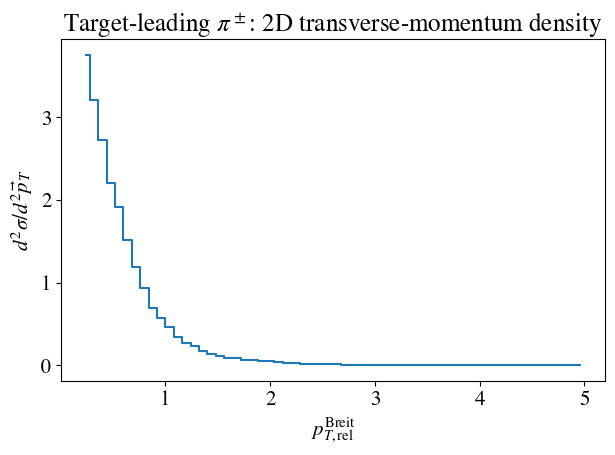

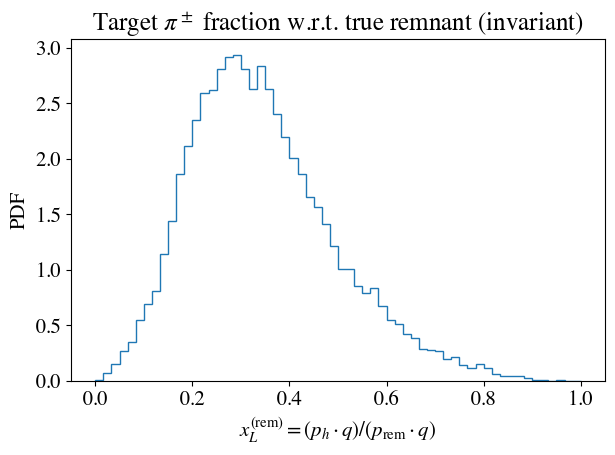

In [15]:
# This is the cell that has ISR and FSR on

import pythia8
import numpy as np
import matplotlib.pyplot as plt

# ---------- helpers ----------
def is_hadron(pid):
    return abs(pid) >= 100

def p3(v):  # v=(E,px,py,pz)
    return np.array([v[1], v[2], v[3]], dtype=float)

def pT_rel_to_axis(p_vec, axis_vec):
    na = np.linalg.norm(axis_vec)
    if na <= 0:
        return None
    n = axis_vec / na
    p_par = np.dot(p_vec, n) * n
    p_perp = p_vec - p_par
    return float(np.linalg.norm(p_perp))

def dot4(a, b):  # Minkowski (+,-,-,-)
    return a[0]*b[0] - a[1]*b[1] - a[2]*b[2] - a[3]*b[3]

def p4(p):  # Pythia particle -> numpy 4-vector
    return np.array([p.e(), p.px(), p.py(), p.pz()], dtype=float)


# ================== Pythia setup ==================
pythia = pythia8.Pythia()

Ee_set = 18.0
Ep_set = 275.0

pythia.readString("Beams:idA = 2212")
pythia.readString("Beams:idB = 11")
pythia.readString(f"Beams:eA = {Ep_set}")
pythia.readString(f"Beams:eB = {Ee_set}")
pythia.readString("Beams:frameType = 2")

pythia.readString("WeakBosonExchange:ff2ff(t:gmZ) = on")
pythia.readString("HardQCD:all = off")

pythia.readString("PDF:lepton = off")
pythia.readString("PartonLevel:ISR = on")
pythia.readString("PartonLevel:FSR = on")
pythia.readString("HadronLevel:all = on")
pythia.readString("ColourReconnection:reconnect = off")

pythia.readString("PhaseSpace:Q2Min = 16.0")
pythia.init()


# ---------------- Analysis cuts ----------------
Qmin, Qmax = 5.0, 15.0
xmin, xmax = 1e-3, 0.5
n_events = 100_000

# ---------------- Outputs ----------------
# pT of leading target pion relative to REMNANT axis (hadron-level, Breit)
pTrel_to_remnant_list_on = []

# your invariant xL with respect to true remnant (same as before)
xL_remnant_list = []

# Track x and Q for events that are kept
x_list = []
Q_list = []

# Diagnostics
n_pass_evt = 0
n_boost = 0
n_have_target_pion = 0
printed_first_event = False  # Flag to print diagnostics once
printed_first_passing_event = False  # Flag to print momenta for first passing event

# Additional diagnostics to track where events are filtered
n_total_events = 0
n_no_pythia_next = 0
n_missing_particles = 0
n_Q2_negative = 0
n_p_dot_q_zero = 0
n_fail_x_cut = 0
n_fail_Q_cut = 0
n_fail_denom_M1 = 0
n_fail_den2 = 0
n_fail_num_log = 0
n_fail_den_log = 0
n_fail_denom_M4 = 0


# ================= EVENT LOOP =================
print(f"Processing {n_events} events...")
for iEvent in range(n_events):
    n_total_events += 1
    
    # Progress indicator every 10% or every 10000 events
    if iEvent > 0 and (iEvent % max(1, n_events // 10) == 0 or iEvent % 10000 == 0):
        print(f"  Processed {iEvent}/{n_events} events ({iEvent/n_events*100:.1f}%) - "
              f"Passed x-Q: {n_pass_evt}, Valid boost: {n_boost}, Target pion: {n_have_target_pion}")

    if not pythia.next():
        n_no_pythia_next += 1
        continue

    ev = pythia.event

    # Identify incoming e, scattered e, proton
    # When ISR/FSR are off, status codes may differ
    e_in = e_sc = p_in = None
    electrons = []  # Collect all electrons to find scattered one
    
    for p in ev:
        pid = p.id()
        status = p.status()
        # Incoming electron: status -12 (incoming beam)
        if pid == 11 and status == -12:
            e_in = p
        # Collect all final/intermediate electrons (for scattered electron identification)
        elif pid == 11 and status > 0:
            electrons.append(p)
        # Incoming proton: status < 0 (incoming)
        elif pid == 2212 and status < 0:
            p_in = p
    
    # Find scattered electron: prefer status 44, otherwise take any electron that's not incoming
    if e_in is not None and electrons:
        for e in electrons:
            if e.status() == 44:  # Preferred: hard process final
                e_sc = e
                break
        # If no status 44 found, take the first electron (when ISR/FSR off, might be status 23 or other)
        if e_sc is None:
            e_sc = electrons[0]

    if not (e_in and e_sc and p_in):
        n_missing_particles += 1
        # Diagnostic: print first few events to see what particles exist
        if n_missing_particles <= 3:
            print(f"\nEvent {iEvent} - Missing particles:")
            print(f"  e_in: {e_in is not None}, e_sc: {e_sc is not None}, p_in: {p_in is not None}")
            # Count particles in event
            event_size = 0
            particles_info = []
            for p in ev:
                event_size += 1
                if event_size <= 10:  # Store first 10 particles
                    particles_info.append((p.id(), p.status(), pythia.particleData.name(p.id())))
            print(f"  Event size: {event_size}")
            print("  Particles in event (first 10):")
            for i, (pid, status, name) in enumerate(particles_info):
                print(f"    [{i}] id={pid}, status={status}, name={name}")
        continue

    Ee, Ep = e_in.e(), p_in.e()

    # Virtual photon
    q0 = e_in.e()  - e_sc.e()
    q1 = e_in.px() - e_sc.px()
    q2 = e_in.py() - e_sc.py()
    q3 = e_in.pz() - e_sc.pz()
    qmu = np.array([q0, q1, q2, q3], dtype=float)

    # Invariants
    Q2 = -(q0*q0 - q1*q1 - q2*q2 - q3*q3)
    if Q2 <= 0:
        n_Q2_negative += 1
        continue
    Q = float(np.sqrt(Q2))
    qT = float(np.hypot(q1, q2))

    p_dot_q = Ep*q0 - Ep*q3
    if p_dot_q == 0:
        n_p_dot_q_zero += 1
        continue

    x = Q2 / (2.0 * p_dot_q)
    if not (xmin <= x <= xmax):
        n_fail_x_cut += 1
        continue
    if not (Qmin <= Q <= Qmax):
        n_fail_Q_cut += 1
        continue

    n_pass_evt += 1

    # Orientation angle for qT rotation
    phiq = float(np.arctan2(q2, q1))
    S = 4.0 * Ee * Ep
    y = Q2 / (S * x)  # inelasticity

    # ---------------- Build your Breit transform ----------------
    Mm1 = np.array([
        [Ee/np.sqrt(S) + np.sqrt(S)/(4.0*Ee), 0,0, Ee/np.sqrt(S) - np.sqrt(S)/(4.0*Ee)],
        [0,1,0,0],
        [0,0,1,0],
        [Ee/np.sqrt(S) - np.sqrt(S)/(4.0*Ee), 0,0, Ee/np.sqrt(S) + np.sqrt(S)/(4.0*Ee)]
    ])

    M0 = np.array([
        [1,0,0,0],
        [0, np.cos(phiq), np.sin(phiq), 0],
        [0,-np.sin(phiq), np.cos(phiq), 0],
        [0,0,0,1]
    ])

    # M1 matrix: matches Mathematica expression exactly
    # denom = 2*y*sqrt(S*(S*(x+1)*y - qT^2))
    denom_M1 = 2.0 * y * np.sqrt(S * (S*(1+x)*y - qT*qT))
    if denom_M1 == 0:
        n_fail_denom_M1 += 1
        continue

    M1 = np.array([
        [(S*y*(x+y+1) - qT*qT) / denom_M1, 0,0,
         (qT*qT + S*y*(-x+y-1)) / denom_M1],
        [0,1,0,0],
        [0,0,1,0],
        [(qT*qT + S*y*(-x+y-1)) / denom_M1, 0,0,
         (S*y*(x+y+1) - qT*qT) / denom_M1]
    ])

    # M2 matrix: matches Mathematica expression exactly
    # den2 = S*(x+1)*y - qT^2
    den2 = S*(1+x)*y - qT*qT
    if den2 <= 0:
        n_fail_den2 += 1
        continue

    # M2[1,1] = 1/sqrt(S*(x+1)*y / (S*(x+1)*y - qT^2))
    denom_M2_s1 = np.sqrt(S*(1+x)*y / den2)
    # M2[1,3] = qT/sqrt(S*(x+1)*y)
    denom_M2_s2 = np.sqrt(S*(1+x)*y)

    M2 = np.array([
        [1,0,0,0],
        [0,1/denom_M2_s1,0, qT/denom_M2_s2],
        [0,0,1,0],
        [0,-qT/denom_M2_s2,0,1/denom_M2_s1]
    ])

    # M3 matrix: matches Mathematica expression exactly
    # M3[0,0] = cosh(0.5*log((qT + sqrt(S*(x+1)*y)) / (sqrt(S*(x+1)*y) - qT)))
    # M3[0,1] = -qT/sqrt(S*(x+1)*y - qT^2)
    denom_M3 = np.sqrt(den2)  # sqrt(S*(x+1)*y - qT^2)
    num_log = qT + np.sqrt(S*(1+x)*y)
    den_log = np.sqrt(S*(1+x)*y) - qT
    if num_log <= 0:
        n_fail_num_log += 1
        continue
    if den_log <= 0:
        n_fail_den_log += 1
        continue

    eta = 0.5*np.log(num_log/den_log)
    M3 = np.array([
        [np.cosh(eta), -qT/denom_M3, 0,0],
        [-qT/denom_M3, np.cosh(eta), 0,0],
        [0,0,1,0],
        [0,0,0,1]
    ])

    denom_M4 = 2*np.sqrt(x*(1+x))
    if denom_M4 == 0:
        n_fail_denom_M4 += 1
        continue

    M4 = np.array([
        [(1+2*x)/denom_M4, 0,0, 1/denom_M4],
        [0,1,0,0],
        [0,0,1,0],
        [1/denom_M4, 0,0,(1+2*x)/denom_M4]
    ])

    # ---------------- Print diagnostics for first event ----------------
    if not printed_first_event:
        printed_first_event = True
        print("=" * 70)
        print("KINEMATIC VARIABLES (before boosts)")
        print("=" * 70)
        print(f"x  = {x:.10f}")
        print(f"y  = {y:.10f}")
        print(f"Q  = {Q:.10f} GeV")
        print(f"qT = {qT:.10f} GeV")
        print(f"phi = {phiq:.10f} radians")
        print(f"S  = {S:.10f} GeV²")
        print(f"Ei = Ee = {Ee:.10f} GeV")
        print(f"Ep = {Ep:.10f} GeV")
        print("=" * 70)
        print("\nMATRICES (for comparison with Mathematica):")
        print("\nMm1 =")
        print(Mm1)
        print("\nM0 =")
        print(M0)
        print("\nM1 =")
        print(M1)
        print("\nM2 =")
        print(M2)
        print("\nM3 =")
        print(M3)
        print("\nM4 =")
        print(M4)
        print()

    # Try both orders - Mathematica might apply in reverse order
    # Standard order: M4 @ M3 @ M2 @ M1 @ M0 @ Mm1
    # Reverse order: Mm1 @ M0 @ M1 @ M2 @ M3 @ M4
    LT = M4 @ M3 @ M2 @ M1 @ M0 @ Mm1
    # If this doesn't work, try: LT = Mm1 @ M0 @ M1 @ M2 @ M3 @ M4

    def boost(v): 
        return LT @ np.array(v)

    n_boost += 1

    # ---------------- Verify Breit frame transformation ----------------
    # Boost photon and proton to Breit frame
    q_breit = boost(qmu)
    p_breit = boost([p_in.e(), p_in.px(), p_in.py(), p_in.pz()])
    
    # Print for first few events to verify
    if n_boost <= 10:
        print(f"\n=== Event {n_boost} ===")
        print(f"Lab frame - Q = {Q:.4f} GeV, x = {x:.4f}, qT = {qT:.4f} GeV")
        print(f"Photon (lab):     E={q0:8.4f}, px={q1:8.4f}, py={q2:8.4f}, pz={q3:8.4f}")
        print(f"Photon (Breit):   E={q_breit[0]:8.4f}, px={q_breit[1]:8.4f}, py={q_breit[2]:8.4f}, pz={q_breit[3]:8.4f}")
        print(f"  |q_Breit| = {np.sqrt(q_breit[1]**2 + q_breit[2]**2 + q_breit[3]**2):.4f} GeV (should be close to Q={Q:.4f})")
        print(f"Proton (lab):     E={p_in.e():8.4f}, px={p_in.px():8.4f}, py={p_in.py():8.4f}, pz={p_in.pz():8.4f}")
        print(f"Proton (Breit):   E={p_breit[0]:8.4f}, px={p_breit[1]:8.4f}, py={p_breit[2]:8.4f}, pz={p_breit[3]:8.4f}")
        print(f"  P+ (Breit) = {p_breit[0] + p_breit[3]:.4f} GeV")

    # ---------------- Proton in Breit (for xL_Breit) ----------------
    P_breit = boost([p_in.e(), p_in.px(), p_in.py(), p_in.pz()])
    P_plus = float(P_breit[0] + P_breit[3])
    if P_plus <= 0:
        continue

    # ---------------- Target region: most energetic hadron must be pi+ or pi- (Breit) ----------------
    best_tarE = -1.0
    best_tar_breit = None
    best_tar_pid = None

    for p in ev:
        if not p.isFinal():
            continue
        if not is_hadron(p.id()):
            continue

        lab = np.array([p.e(), p.px(), p.py(), p.pz()])
        trf = boost(lab)
        E_, px_, py_, pz_ = trf

        if pz_ <= 0:
            continue  # target hemisphere

        if E_ > best_tarE:
            best_tarE = E_
            best_tar_breit = trf
            best_tar_pid = p.id()

    if best_tar_breit is None:
        continue

    # require the most energetic TARGET hadron is pi+ or pi-
    if abs(best_tar_pid) != 211:
        continue
    n_have_target_pion += 1

    # boost q into Breit so dot-products are consistent
    q_breit = boost([q0, q1, q2, q3])

    # ---------------- Find struck quark using Pythia hard process information ----------------
    # Find outgoing hard quark (truth)
    # In Pythia8, hard process quarks typically have status 23 (hard process intermediate)
    # or status 63-68 (hard process final)
    k_out = None
    
    # First try: look for quarks with status 23 (hard process intermediate)
    for pp in ev:
        pid = pp.id()
        status = abs(pp.status())
        if 1 <= abs(pid) <= 6 and status == 23:  # quark with hard process status
            k_out = p4(pp)
            break
    
    # Second try: look for quarks with status 63-68 (hard process final)
    if k_out is None:
        for pp in ev:
            pid = pp.id()
            status = abs(pp.status())
            if 1 <= abs(pid) <= 6 and 63 <= status <= 68:  # quark with hard process final status
                k_out = p4(pp)
                break
    
    # Third try: look for any quark with positive status (not incoming)
    if k_out is None:
        for pp in ev:
            pid = pp.id()
            status = pp.status()
            if 1 <= abs(pid) <= 6 and status > 0:  # any outgoing quark
                k_out = p4(pp)
                break

    if k_out is None:
        # couldn't identify the outgoing hard quark in this event
        continue

    k_in = k_out - qmu                 # incoming struck parton (truth)
    p_rem_truth = p4(p_in) - k_in      # proton remnant before hadronization

    # ---------------- True remnant momentum (sum over target hemisphere final state) ----------------
    p_rem = np.zeros(4)
    for pp in ev:
        if not pp.isFinal():
            continue
        lab_pp = np.array([pp.e(), pp.px(), pp.py(), pp.pz()])
        trf = boost(lab_pp)
        if trf[3] > 0:   # target hemisphere
            p_rem += trf

    # Boost truth-level momenta to Breit frame
    p_proton_breit = boost([p_in.e(), p_in.px(), p_in.py(), p_in.pz()])
    k_in_breit = boost(k_in)
    k_out_breit = boost(k_out)
    p_rem_truth_breit = boost(p_rem_truth)

    # ---------------- Print momenta for first passing event ----------------
    if not printed_first_passing_event:
        printed_first_passing_event = True
        print("\n" + "=" * 70)
        print("MOMENTA FOR FIRST PASSING EVENT (Breit Frame)")
        print("=" * 70)
        print(f"\nPhoton momentum (q_breit):")
        print(f"  E  = {q_breit[0]:12.6f} GeV")
        print(f"  px = {q_breit[1]:12.6f} GeV")
        print(f"  py = {q_breit[2]:12.6f} GeV")
        print(f"  pz = {q_breit[3]:12.6f} GeV")
        print(f"  |q| = {np.sqrt(q_breit[1]**2 + q_breit[2]**2 + q_breit[3]**2):12.6f} GeV (should be close to Q={Q:.6f} GeV)")
        print(f"\nStruck quark momentum (from Pythia hard process):")
        print(f"  Incoming struck quark (k_in) in Breit frame:")
        print(f"    E  = {k_in_breit[0]:12.6f} GeV")
        print(f"    px = {k_in_breit[1]:12.6f} GeV")
        print(f"    py = {k_in_breit[2]:12.6f} GeV")
        print(f"    pz = {k_in_breit[3]:12.6f} GeV")
        print(f"    |p| = {np.sqrt(k_in_breit[1]**2 + k_in_breit[2]**2 + k_in_breit[3]**2):12.6f} GeV")
        print(f"  Outgoing quark (k_out) in Breit frame:")
        print(f"    E  = {k_out_breit[0]:12.6f} GeV")
        print(f"    px = {k_out_breit[1]:12.6f} GeV")
        print(f"    py = {k_out_breit[2]:12.6f} GeV")
        print(f"    pz = {k_out_breit[3]:12.6f} GeV")
        print(f"    |p| = {np.sqrt(k_out_breit[1]**2 + k_out_breit[2]**2 + k_out_breit[3]**2):12.6f} GeV")
        print(f"\nProton remnant momentum:")
        print(f"  Truth-level remnant (p_rem_truth) in Breit frame:")
        print(f"    E  = {p_rem_truth_breit[0]:12.6f} GeV")
        print(f"    px = {p_rem_truth_breit[1]:12.6f} GeV")
        print(f"    py = {p_rem_truth_breit[2]:12.6f} GeV")
        print(f"    pz = {p_rem_truth_breit[3]:12.6f} GeV")
        print(f"    |p| = {np.sqrt(p_rem_truth_breit[1]**2 + p_rem_truth_breit[2]**2 + p_rem_truth_breit[3]**2):12.6f} GeV")
        print(f"  Hadron-level remnant (p_rem) in Breit frame:")
        print(f"    E  = {p_rem[0]:12.6f} GeV")
        print(f"    px = {p_rem[1]:12.6f} GeV")
        print(f"    py = {p_rem[2]:12.6f} GeV")
        print(f"    pz = {p_rem[3]:12.6f} GeV")
        print(f"    |p| = {np.sqrt(p_rem[1]**2 + p_rem[2]**2 + p_rem[3]**2):12.6f} GeV")
        print(f"\nProton momentum in Breit frame (for reference):")
        print(f"  E  = {p_proton_breit[0]:12.6f} GeV")
        print(f"  px = {p_proton_breit[1]:12.6f} GeV")
        print(f"  py = {p_proton_breit[2]:12.6f} GeV")
        print(f"  pz = {p_proton_breit[3]:12.6f} GeV")
        print(f"  P+ = {p_proton_breit[0] + p_proton_breit[3]:12.6f} GeV")
        print(f"\nTarget-leading pion momentum (best_tar_breit):")
        print(f"  E  = {best_tar_breit[0]:12.6f} GeV")
        print(f"  px = {best_tar_breit[1]:12.6f} GeV")
        print(f"  py = {best_tar_breit[2]:12.6f} GeV")
        print(f"  pz = {best_tar_breit[3]:12.6f} GeV")
        print(f"  |p| = {np.sqrt(best_tar_breit[1]**2 + best_tar_breit[2]**2 + best_tar_breit[3]**2):12.6f} GeV")
        print(f"  PID = {best_tar_pid}")
        print("=" * 70)
        print()

    # ---------------- pTrel of leading target pion w.r.t. remnant axis ----------------
    # Use truth-level remnant momentum (before hadronization) as axis
    axis_rem = p3(p_rem_truth_breit)
    if np.linalg.norm(axis_rem) <= 0:
        continue

    pTrel_rem = pT_rel_to_axis(p3(best_tar_breit), axis_rem)
    if pTrel_rem is None:
        continue

    # ---------------- invariant xL (using truth-level remnant) ----------------
    den = dot4(p_rem_truth_breit, q_breit)
    if den <= 0:
        continue

    xL_exact = dot4(best_tar_breit, q_breit) / den
    if xL_exact < 0.01 or xL_exact > 1.0 + 1e-6:
        continue

    pTrel_to_remnant_list_on.append(pTrel_rem)
    xL_remnant_list.append(xL_exact)
    
    # Track x and Q for this event
    x_list.append(x)
    Q_list.append(Q)


# ================= PLOTS =================
plt.figure()

counts, edges = np.histogram(
    pTrel_to_remnant_list_on,
    bins=60,
    range=(0.2, 5),   # avoid pT = 0
    density=True
)

centers = 0.5 * (edges[:-1] + edges[1:])
binw = edges[1:] - edges[:-1]

# Convert to 2D density: d²σ/d²p_T = (1/p_T) dσ/dp_T
# where dσ/dp_T is the 1D density from histogram (normalized to 1 by density=True)
y2d = counts / centers  # This gives d²σ/d²p_T

# Check normalization
# 1D normalization: ∫ dp_T (dσ/dp_T) should be ≈ 1.0 (from density=True)
norm_1d = np.sum(counts * binw)
print(f"\nNormalization check:")
print(f"  1D normalization: ∫ dp_T (dσ/dp_T) = {norm_1d:.6f} (should be ≈ 1.0)")

# 2D normalization: ∫ d²p_T d²σ/d²p_T = ∫ dp_T (2π p_T) d²σ/d²p_T
#                   = 2π ∫ dp_T p_T (1/p_T) dσ/dp_T
#                   = 2π ∫ dp_T dσ/dp_T = 2π
norm_2d = 2.0 * np.pi * np.sum(centers * binw * y2d)
print(f"  2D normalization: 2π ∫ dp_T p_T (d²σ/d²p_T) = {norm_2d:.6f} (should be ≈ 2π ≈ {2*np.pi:.6f})")

# Verify: ∫ d²p_T d²σ/d²p_T = ∫ dp_T (2π p_T) y2d should equal 2π
print(f"  Verification: ∫ d²p_T d²σ/d²p_T = {norm_2d:.6f} (should equal 2π)")

plt.step(centers, y2d, where="mid")

plt.xlabel(r"$p_{T,\mathrm{rel}}^{\mathrm{Breit}}$")
plt.ylabel(r"$d^2\sigma/d^2\vec p_T$")
plt.title(r"Target-leading $\pi^\pm$: 2D transverse-momentum density")
plt.tight_layout()
plt.savefig("pTrel_target_pion_wrt_remnant_axis_2D.png", dpi=180)

plt.figure()
plt.hist(xL_remnant_list, bins=60, range=(0,1), histtype="step", density=True)
plt.xlabel(r"$x_L^{\mathrm{(rem)}} = (p_h\cdot q)/(p_{\rm rem}\cdot q)$")
plt.ylabel("PDF")
plt.title(r"Target $\pi^\pm$ fraction w.r.t. true remnant (invariant)")
plt.tight_layout()
plt.savefig("xL_target_pion_remnant_invariant.png", dpi=180)

print("\nSummary:")
print(f"Total events processed:       {n_total_events}")
print(f"Events passing (x,Q):        {n_pass_evt}")
print(f"Events w/ target-leading pion: {n_have_target_pion}")
print(f"Events kept (filled observables): {len(pTrel_to_remnant_list)}")
if len(x_list) > 0:
    print(f"Average x:                    {np.mean(x_list):.6f}")
    print(f"Average Q:                    {np.mean(Q_list):.6f} GeV")
print("\nDiagnostics - Events filtered BEFORE x-Q cuts:")
print(f"  Failed pythia.next():      {n_no_pythia_next}")
print(f"  Missing particles:          {n_missing_particles}")
print(f"  Q2 <= 0:                    {n_Q2_negative}")
print(f"  p_dot_q == 0:               {n_p_dot_q_zero}")
print(f"  Failed x cut ({xmin} <= x <= {xmax}): {n_fail_x_cut}")
print(f"  Failed Q cut ({Qmin} <= Q <= {Qmax}): {n_fail_Q_cut}")
print("\nDiagnostics - Events filtered AFTER x-Q cuts:")
print(f"  Failed denom_M1 check:     {n_fail_denom_M1}")
print(f"  Failed den2 <= 0 check:    {n_fail_den2}")
print(f"  Failed num_log <= 0:       {n_fail_num_log}")
print(f"  Failed den_log <= 0:       {n_fail_den_log}")
print(f"  Failed denom_M4 == 0:      {n_fail_denom_M4}")
print(f"  Total filtered after x-Q:  {n_fail_denom_M1 + n_fail_den2 + n_fail_num_log + n_fail_den_log + n_fail_denom_M4}")
print(f"  Events with valid boost:   {n_boost}")
if n_pass_evt > 0:
    print(f"  Efficiency:                {n_boost/n_pass_evt*100:.2f}%")
else:
    print(f"  Efficiency:                N/A (no events passed x-Q cuts)")



Gaussian fit to 2D density for pT < 1.00 GeV (single width parameter):
B  = 0.4422721366247723   (so width sqrt(<pT^2>) = sqrt(B) = 0.6650354401268945 )
A  = 4.523666253565686   (determined from normalization)


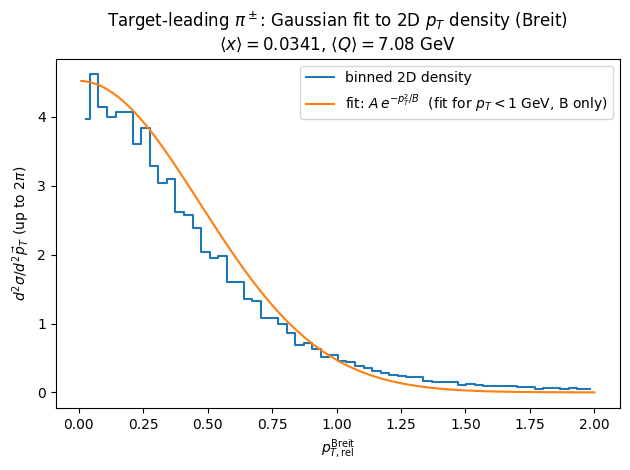

In [63]:
# ================= Fit d^2σ/d^2pT with a Gaussian for pT < 2 GeV =================
pTmax_fit = 1.0
eps = 1e-12  # guard against log(0)

# histogram for dσ/dpT (density=True gives normalized 1D pdf in pT)
counts, edges = np.histogram(
    pTrel_to_remnant_list_on,
    bins=60,
    range=(0.01, 2.0),
    density=True
)
centers = 0.5 * (edges[:-1] + edges[1:])
binw = edges[1:] - edges[:-1]

# Convert to 2D density up to an overall (2π) factor:
# d^2σ/d^2pT ∝ (1/pT) dσ/dpT  --> y = counts / centers
y2d = counts / centers

# Statistical uncertainty estimate (optional but helpful):
# For N events, expected count in bin i ~ N * pdf_i * Δp
# So σ(pdf_i) ~ sqrt(n_i)/(N*Δp). Here we estimate n_i from pdf_i.
N = len(pTrel_to_remnant_list_on)
n_i_est = np.maximum(N * counts * binw, 1.0)  # avoid zeros
sigma_counts = np.sqrt(n_i_est) / (N * binw)  # σ on counts (pdf)
sigma_y2d = sigma_counts / centers            # propagate to y2d

# Fit region mask
mask = (centers < pTmax_fit) & (y2d > 0) & np.isfinite(y2d) & np.isfinite(sigma_y2d)

# Fit with single width parameter B only (no normalization A)
# Model: y = A * exp(-p_T^2 / B) where A is determined by normalization
# We fit only B, then determine A from the normalization constraint

# Fit in log-space: ln y = lnA - pT^2 / B
# For fixed normalization, we fit only the slope (B), not the intercept (A)
X = centers[mask]**2
Y = np.log(y2d[mask] + eps)

# weights for log fit: σ(ln y) ≈ σ_y / y
sigma_lnY = sigma_y2d[mask] / (y2d[mask] + eps)
w = 1.0 / np.maximum(sigma_lnY, 1e-6)**2

# Fit only the slope (c1 = -1/B), removing normalization dependence
# We center the data to remove the intercept term
Y_mean = np.average(Y, weights=w)
Y_centered = Y - Y_mean
X_mean = np.average(X, weights=w)
X_centered = X - X_mean

# Weighted linear regression for slope only: Y_centered = c1 * X_centered
# c1 = Σ(w * X_centered * Y_centered) / Σ(w * X_centered^2)
numerator = np.sum(w * X_centered * Y_centered)
denominator = np.sum(w * X_centered**2)
c1 = numerator / denominator if denominator > 0 else 0.0

# Map to width parameter: c1 = -1/B
B_fit = float(-1.0 / c1) if c1 < 0 else 1.0

# Determine A from normalization constraint
# For normalized 2D distribution: 2π ∫ dp_T p_T A exp(-p_T^2/B) = 2π
# This gives: A = 2/B
# But to match the actual data normalization, we compute A numerically
p_integrate = np.linspace(0.01, 2.0, 1000)
integrand = p_integrate * np.exp(-(p_integrate**2) / B_fit)
integral = np.trapz(integrand, p_integrate)
A_fit = 1.0 / integral if integral > 0 else 1.0

print("\nGaussian fit to 2D density for pT < %.2f GeV (single width parameter):" % pTmax_fit)
print("B  =", B_fit, "  (so width sqrt(<pT^2>) = sqrt(B) =", np.sqrt(B_fit), ")")
print("A  =", A_fit, "  (determined from normalization)")

# Calculate average x and Q for the plot title
avg_x = np.mean(x_list) if len(x_list) > 0 else 0.0
avg_Q = np.mean(Q_list) if len(Q_list) > 0 else 0.0

# Overlay plot
plt.figure()
plt.step(centers, y2d, where="mid", label="binned 2D density")

p_grid = np.linspace(0.01, 2.0, 200)
y_fit = A_fit * np.exp(-(p_grid**2) / B_fit)
plt.plot(p_grid, y_fit, label=r"fit: $A\,e^{-p_T^2/B}$  (fit for $p_T<1$ GeV, B only)")

plt.xlabel(r"$p_{T,\mathrm{rel}}^{\mathrm{Breit}}$")
plt.ylabel(r"$d^2\sigma/d^2\vec p_T$ (up to $2\pi$)")
plt.title(r"Target-leading $\pi^\pm$: Gaussian fit to 2D $p_T$ density (Breit)" + 
          f"\n$\\langle x \\rangle = {avg_x:.4f}$, $\\langle Q \\rangle = {avg_Q:.2f}$ GeV")
plt.legend()
plt.tight_layout()
plt.savefig("pTrel_target_pion_wrt_remnant_axis_2D_fit_gaussian.png", dpi=180)


In [ ]:
# ================= Fit d^2σ/d^2pT with a Gaussian for pT < 2 GeV =================
pTmax_fit = 1.0
eps = 1e-12  # guard against log(0)

# histogram for dσ/dpT (density=True gives normalized 1D pdf in pT)
counts, edges = np.histogram(
    pTrel_to_remnant_list_on,
    bins=60,
    range=(0.01, 2.0),
    density=True
)
centers = 0.5 * (edges[:-1] + edges[1:])
binw = edges[1:] - edges[:-1]

# Convert to 2D density up to an overall (2π) factor:
# d^2σ/d^2pT ∝ (1/pT) dσ/dpT  --> y = counts / centers
y2d = counts / centers

# Statistical uncertainty estimate (optional but helpful):
# For N events, expected count in bin i ~ N * pdf_i * Δp
# So σ(pdf_i) ~ sqrt(n_i)/(N*Δp). Here we estimate n_i from pdf_i.
N = len(pTrel_to_remnant_list_on)
n_i_est = np.maximum(N * counts * binw, 1.0)  # avoid zeros
sigma_counts = np.sqrt(n_i_est) / (N * binw)  # σ on counts (pdf)
sigma_y2d = sigma_counts / centers            # propagate to y2d

# Fit region mask
mask = (centers < pTmax_fit) & (y2d > 0) & np.isfinite(y2d) & np.isfinite(sigma_y2d)

# Fit with single width parameter B only (no normalization A)
# Model: y = A * exp(-p_T^2 / B) where A is determined by normalization
# We fit only B, then determine A from the normalization constraint

# Fit in log-space: ln y = lnA - pT^2 / B
# For fixed normalization, we fit only the slope (B), not the intercept (A)
X = centers[mask]**2
Y = np.log(y2d[mask] + eps)

# weights for log fit: σ(ln y) ≈ σ_y / y
sigma_lnY = sigma_y2d[mask] / (y2d[mask] + eps)
w = 1.0 / np.maximum(sigma_lnY, 1e-6)**2

# Fit only the slope (c1 = -1/B), removing normalization dependence
# We center the data to remove the intercept term
Y_mean = np.average(Y, weights=w)
Y_centered = Y - Y_mean
X_mean = np.average(X, weights=w)
X_centered = X - X_mean

# Weighted linear regression for slope only: Y_centered = c1 * X_centered
# c1 = Σ(w * X_centered * Y_centered) / Σ(w * X_centered^2)
numerator = np.sum(w * X_centered * Y_centered)
denominator = np.sum(w * X_centered**2)
c1 = numerator / denominator if denominator > 0 else 0.0

# Map to width parameter: c1 = -1/B
B_fit = float(-1.0 / c1) if c1 < 0 else 1.0

# Determine A from normalization constraint
# For normalized 2D distribution: 2π ∫ dp_T p_T A exp(-p_T^2/B) = 2π
# This gives: A = 2/B
# But to match the actual data normalization, we compute A numerically
p_integrate = np.linspace(0.01, 2.0, 1000)
integrand = p_integrate * np.exp(-(p_integrate**2) / B_fit)
integral = np.trapz(integrand, p_integrate)
A_fit = 1.0 / integral if integral > 0 else 1.0

print("\nGaussian fit to 2D density for pT < %.2f GeV (single width parameter):" % pTmax_fit)
print("B  =", B_fit, "  (so width sqrt(<pT^2>) = sqrt(B) =", np.sqrt(B_fit), ")")
print("A  =", A_fit, "  (determined from normalization)")

# Calculate average x and Q for the plot title
avg_x = np.mean(x_list) if len(x_list) > 0 else 0.0
avg_Q = np.mean(Q_list) if len(Q_list) > 0 else 0.0

# Overlay plot
plt.figure()
plt.step(centers, y2d, where="mid", label="binned 2D density")

p_grid = np.linspace(0.01, 2.0, 200)
y_fit = A_fit * np.exp(-(p_grid**2) / B_fit)
plt.plot(p_grid, y_fit, label=r"fit: $A\,e^{-p_T^2/B}$  (fit for $p_T<1$ GeV, B only)")

plt.xlabel(r"$p_{T,\mathrm{rel}}^{\mathrm{Breit}}$")
plt.ylabel(r"$d^2\sigma/d^2\vec p_T$ (up to $2\pi$)")
plt.title(r"Target-leading $\pi^\pm$: Gaussian fit to 2D $p_T$ density (Breit)" + 
          f"\n$\\langle x \\rangle = {avg_x:.4f}$, $\\langle Q \\rangle = {avg_Q:.2f}$ GeV")
plt.legend()
plt.tight_layout()
plt.savefig("pTrel_target_pion_wrt_remnant_axis_2D_fit_gaussian.png", dpi=180)


In [ ]:
counts, edges = np.histogram(pTrel_to_remnant_list, bins=60, range=(0,5), density=True)
binw = edges[1:] - edges[:-1]
norm_1D = np.sum(counts * binw)   # Riemann sum for ∫ dp (dσ/dp)

print("Riemann check: ∫ dpT (dσ/dpT) ≈", norm_1D)


Riemann check: ∫ dpT (dσ/dpT) ≈ 1.0


In [59]:
import pythia8
import numpy as np
import matplotlib.pyplot as plt

# ---------- helpers ----------
def dot(a, b):  # (+,-,-,-)
    return a[0]*b[0] - a[1]*b[1] - a[2]*b[2] - a[3]*b[3]

def is_hadron(pid):
    return abs(pid) >= 100  # any hadron

# ================== Pythia setup ==================
pythia = pythia8.Pythia()
pythia.readString("Beams:idA = 2212")
pythia.readString("Beams:idB = 11")
pythia.readString("Beams:eA = 275.0")
pythia.readString("Beams:eB = 18.00")
pythia.readString("Beams:frameType = 2")
pythia.readString("WeakBosonExchange:ff2ff(t:gmZ) = on")
pythia.readString("PDF:lepton = off")
pythia.readString("ColourReconnection:reconnect = on")
pythia.readString("PhaseSpace:Q2Min = 2025.0")
pythia.init()

# Kinematic windows
Qmin, Qmax = 1.00, 25.0
xmin, xmax = 0.10, 0.99
n_events = 5_000  # adjust as needed

# Output container for fragmenting-quark transverse momentum
kT_list = []

# Diagnostics
n_pass_evt = n_boost = 0
n_have_target = 0

# ================= EVENT LOOP =================
for iEvent in range(n_events):

    if not pythia.next():
        continue

    ev = pythia.event

    # Identify incoming e, scattered e, proton
    e_in = e_sc = p_in = None
    for p in ev:
        if p.id() == 11 and p.status() == -12: e_in = p
        elif p.id() == 11 and p.status() == 44: e_sc = p
        elif p.id() == 2212 and p.status() < 0: p_in = p

    if not (e_in and e_sc and p_in):
        continue

    Ee, Ep = e_in.e(), p_in.e()

    # Virtual photon
    q0 = e_in.e()  - e_sc.e()
    q1 = e_in.px() - e_sc.px()
    q2 = e_in.py() - e_sc.py()
    q3 = e_in.pz() - e_sc.pz()
    qmu = np.array([q0, q1, q2, q3])

    # Invariants
    Q2 = -(q0*q0 - q1*q1 - q2*q2 - q3*q3)
    if Q2 <= 0:
        continue

    Q = float(np.sqrt(Q2))
    qT = float(np.hypot(q1, q2))

    p_dot_q = Ep*q0 - Ep*q3
    if p_dot_q == 0: 
        continue

    x = Q2 / (2.0 * p_dot_q)
    if not (xmin <= x <= xmax):
        continue
    if not (Qmin <= Q <= Qmax):
        continue

    n_pass_evt += 1

    # Orientation angle for qT rotation
    phiq = float(np.arctan2(q2, q1))
    S = 4.0 * Ee * Ep

    # ---------------- Build your Breit transform ----------------
    Mm1 = np.array([
        [Ee/np.sqrt(S) + np.sqrt(S)/(4.0*Ee), 0,0, Ee/np.sqrt(S) - np.sqrt(S)/(4.0*Ee)],
        [0,1,0,0],
        [0,0,1,0],
        [Ee/np.sqrt(S) - np.sqrt(S)/(4.0*Ee), 0,0, Ee/np.sqrt(S) + np.sqrt(S)/(4.0*Ee)]
    ])

    M0 = np.array([
        [1,0,0,0],
        [0, np.cos(phiq), np.sin(phiq), 0],
        [0,-np.sin(phiq), np.cos(phiq), 0],
        [0,0,0,1]
    ])

    denom_M1 = 2.0 * x * np.sqrt(S * (-qT*qT + S*(1+x)*x))
    if denom_M1 == 0:
        continue

    M1 = np.array([
        [(-qT*qT + S*x*(1+x+x)) / denom_M1, 0,0,
         ( qT*qT + S*x*(-1-x+x)) / denom_M1],
        [0,1,0,0],
        [0,0,1,0],
        [( qT*qT + S*x*(-1-x+x)) / denom_M1, 0,0,
         (-qT*qT + S*x*(1+x+x)) / denom_M1]
    ])

    den2 = (-qT*qT + S*(1+x)*x)
    if den2 <= 0:
        continue

    denom_M2_s1 = np.sqrt(S*(1+x)*x / den2)
    denom_M2_s2 = np.sqrt(S*(1+x)*x)

    M2 = np.array([
        [1,0,0,0],
        [0,1/denom_M2_s1,0, qT/denom_M2_s2],
        [0,0,1,0],
        [0,-qT/denom_M2_s2,0,1/denom_M2_s1]
    ])

    denom_M3 = np.sqrt(den2)
    num_log = qT + np.sqrt(S*(1+x)*x)
    den_log = -qT + np.sqrt(S*(1+x)*x)
    if num_log <= 0 or den_log <= 0:
        continue

    eta = 0.5*np.log(num_log/den_log)
    M3 = np.array([
        [np.cosh(eta), -qT/denom_M3, 0,0],
        [-qT/denom_M3, np.cosh(eta), 0,0],
        [0,0,1,0],
        [0,0,0,1]
    ])

    denom_M4 = 2*np.sqrt(x*(1+x))
    if denom_M4 == 0:
        continue

    M4 = np.array([
        [(1+2*x)/denom_M4, 0,0, 1/denom_M4],
        [0,1,0,0],
        [0,0,1,0],
        [1/denom_M4, 0,0,(1+2*x)/denom_M4]
    ])

    LT = M4 @ M3 @ M2 @ M1 @ M0 @ Mm1
    def boost(v): return LT @ np.array(v)

    n_boost += 1

    # ---------------- Tag target hadron ----------------
    best_E = -1.0
    best_lab = None
    best_trf = None

    for p in ev:
        if not p.isFinal(): 
            continue
        if not is_hadron(p.id()):
            continue

        # LAB 4-vector
        lab = np.array([p.e(), p.px(), p.py(), p.pz()])

        # Transform to Breit
        trf = boost(lab)
        E_, px_, py_, pz_ = trf

        if pz_ <= 0:
            continue  # require target hemisphere

        if E_ > best_E:
            best_E = E_
            best_lab = lab
            best_trf = trf

    if best_trf is None:
        continue

    n_have_target += 1

    # ---------------- Compute pT/Q/xL ----------------
    E_lab, px_lab, py_lab, pz_lab = best_lab
    xL = E_lab / Ep   # energy fraction in lab frame

    E_, px_, py_, pz_ = best_trf
    pT = np.sqrt(px_*px_ + py_*py_)

    if xL > 0:
        kT = pT / (Q * xL)
        kT_list.append(kT)

# ================= PLOT =================
plt.figure()
plt.hist(kT_list, bins=50, range=(0,1),
         histtype="step", color="k", density=True)
plt.xlabel(r"$p_T'/(Q\,x_L)$")
plt.ylabel("PDF")
plt.title("Normalized distribution of $p_T'/(Q x_L)$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("kT_fragmenting_quark_normalized.png", dpi=180)


print("\nSummary:")
print(f"Events passing (x,Q): {n_pass_evt}")
print(f"Breit transforms:     {n_boost}")
print(f"Target hadrons:       {n_have_target}")
print(f"kT values:            {len(kT_list)}")



 *------------------------------------------------------------------------------------* 
 |                                                                                    | 
 |  *------------------------------------------------------------------------------*  | 
 |  |                                                                              |  | 
 |  |                                                                              |  | 
 |  |   PPP   Y   Y  TTTTT  H   H  III    A      Welcome to the Lund Monte Carlo!  |  | 
 |  |   P  P   Y Y     T    H   H   I    A A     This is PYTHIA version 8.312      |  | 
 |  |   PPP     Y      T    HHHHH   I   AAAAA    Last date of change: 23 May 2024  |  | 
 |  |   P       Y      T    H   H   I   A   A                                      |  | 
 |  |   P       Y      T    H   H  III  A   A    Now is 22 Jan 2026 at 10:39:32    |  | 
 |  |                                                                              |  | 
 |  |   Program docu

KeyboardInterrupt: 

In [12]:
print(kT_list)

[]



 *------------------------------------------------------------------------------------* 
 |                                                                                    | 
 |  *------------------------------------------------------------------------------*  | 
 |  |                                                                              |  | 
 |  |                                                                              |  | 
 |  |   PPP   Y   Y  TTTTT  H   H  III    A      Welcome to the Lund Monte Carlo!  |  | 
 |  |   P  P   Y Y     T    H   H   I    A A     This is PYTHIA version 8.312      |  | 
 |  |   PPP     Y      T    HHHHH   I   AAAAA    Last date of change: 23 May 2024  |  | 
 |  |   P       Y      T    H   H   I   A   AInitialized JLab COM simulation with sqrt(s)=4.53 GeV
                                      |  | 
 |  |   P       Y      T    H   H  III  A   A    Now is 10 Dec 2025 at 19:59:04    |  | 
 |  |                                                  

/usr/local/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Saved: kT_JLab.png


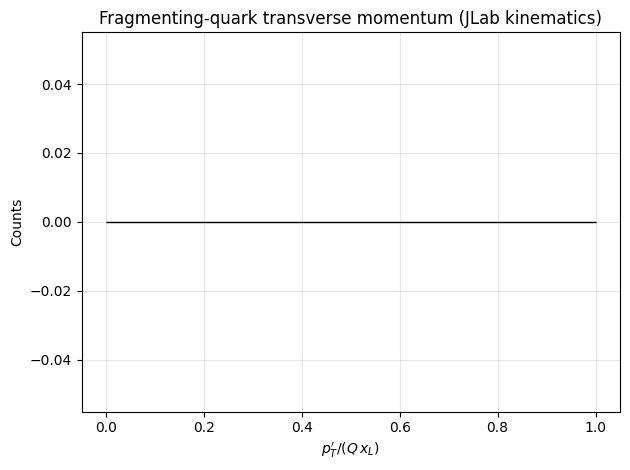

In [7]:
import pythia8
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Helpers ----------------
def dot(a, b):  # (+,-,-,-)
    return a[0]*b[0] - a[1]*b[1] - a[2]*b[2] - a[3]*b[3]

def is_hadron(pid):
    return abs(pid) >= 100  # any hadron

# ================== Pythia: Jefferson Lab setup ==================
pythia = pythia8.Pythia()

# Jefferson Lab true COM energy
sqrtS = 4.53                 # GeV
Ebeam = sqrtS / 2.0          # 2.265 GeV each beam

pythia.readString("Beams:frameType = 2")   # COM frame
pythia.readString("Beams:idA = 11")        # electron
pythia.readString("Beams:idB = 2212")      # proton
pythia.readString(f"Beams:eA = {Ebeam}")   # 2.265 GeV
pythia.readString(f"Beams:eB = {Ebeam}")   # same

# DIS configuration
pythia.readString("WeakBosonExchange:ff2ff(t:gmZ) = on")
pythia.readString("HardQCD:all = on")
pythia.readString("PDF:lepton = off")
pythia.readString("ColourReconnection:reconnect = on")

# Allow low-to-moderate Q2 typical of JLab physics
pythia.readString("PhaseSpace:Q2Min = 0.5")

pythia.init()
print("Initialized JLab COM simulation with sqrt(s)=4.53 GeV")

# Kinematic windows
Qmin, Qmax = 1.0, 10.0
xmin, xmax = 0.10, 0.99
n_events = 50_000  # adjust as needed

# storage
kT_list = []    # pT'/(Q x_L)
Qvals   = []     # Q values
xLvals  = []     # x_L values

# diagnostics
n_pass_evt = 0
n_have_target = 0


# ==================== Event loop ====================
for iEvent in range(n_events):

    if not pythia.next():
        continue

    ev = pythia.event

    # Identify incoming & scattered electron
    e_in = e_sc = None
    p_in = None

    for p in ev:
        if p.id() == 11 and p.status() == -12: e_in = p
        elif p.id() == 11 and p.status() == 44: e_sc = p
        elif p.id() == 2212 and p.status() < 0: p_in = p

    if not (e_in and e_sc and p_in):
        continue

    Ee = e_in.e()
    Ep = p_in.e()   # ≈ 0.938 GeV

    # Photon 4-vector
    q0 = e_in.e()  - e_sc.e()
    q1 = e_in.px() - e_sc.px()
    q2 = e_in.py() - e_sc.py()
    q3 = e_in.pz() - e_sc.pz()
    qmu = np.array([q0, q1, q2, q3])

    # Invariants
    Q2 = -(q0*q0 - q1*q1 - q2*q2 - q3*q3)
    if Q2 <= 0:
        continue

    Q = float(np.sqrt(Q2))
    qT = float(np.hypot(q1, q2))

    # Bjorken x using x = Q²/(2 p⋅q)
    p_vec = np.array([Ep, 0, 0, 0])
    p_dot_q = dot(p_vec, qmu)
    if p_dot_q == 0:
        continue

    x = Q2 / (2.0 * p_dot_q)
    if not (0.05 < x < 0.95):
        continue

    n_pass_evt += 1

    # =============== Simple Breit-like boost ===============
    # Rotate qT to x-axis
    phi = np.arctan2(q2, q1)
    cosf, sinf = np.cos(phi), np.sin(phi)

    R = np.array([
        [1,    0,     0,   0],
        [0,  cosf,  sinf,  0],
        [0, -sinf,  cosf,  0],
        [0,    0,     0,   1]
    ])

    q_rot = R @ qmu
    qz = q_rot[3]

    # Boost along z to make q' purely spacelike: q' = (0,0,0,-Q)
    beta = q_rot[0] / qz
    if abs(beta) >= 1:
        continue

    gamma = 1.0 / np.sqrt(1 - beta*beta)

    B = np.array([
        [gamma, 0, 0, -gamma*beta],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [-gamma*beta, 0, 0, gamma]
    ])

    LT = B @ R

    def boost(v):
        return LT @ np.array(v)


    # ================= Target-region hadron =================
    best_E = -1.0
    best_lab = None
    best_trf = None

    for p in ev:
        if not p.isFinal(): 
            continue
        if not is_hadron(p.id()):
            continue

        lab = np.array([p.e(), p.px(), p.py(), p.pz()])
        trf = boost(lab)

        E_, px_, py_, pz_ = trf

        if pz_ <= 0:
            continue  # require target hemisphere

        if E_ > best_E:
            best_E = E_
            best_lab = lab
            best_trf = trf

    if best_trf is None:
        continue

    n_have_target += 1

    # ================= Compute pT/(Q x_L) =================
    E_lab = best_lab[0]
    x_L = E_lab / Ep      # JLab definition of x_L

    E_, px_, py_, pz_ = best_trf
    pT = np.sqrt(px_*px_ + py_*py_)

    if x_L > 0:
        kT = pT / (Q * x_L)
        kT_list.append(kT)
        Qvals.append(Q)
        xLvals.append(x_L)


# ==================== Summary ====================

print("\n===== JLab Fragmenting-quark kT Summary =====")
print(f"Events passing DIS cuts:     {n_pass_evt}")
print(f"Events with target hadron:   {n_have_target}")
print(f"Total kT measurements:       {len(kT_list)}")
print(f"\nAverage Q:    {np.mean(Qvals):.3f} GeV")
print(f"Average x_L:  {np.mean(xLvals):.3f}")


# ==================== Plot ====================
plt.figure()
plt.hist(kT_list, bins=50, histtype="step", color="k")
plt.xlabel(r"$p_T'/(Q\,x_L)$")
plt.ylabel("Counts")
plt.title("Fragmenting-quark transverse momentum (JLab kinematics)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("kT_JLab.png", dpi=180)

print("\nSaved: kT_JLab.png")



 --------  PYTHIA Info Listing  ---------------------------------------- 
 
 Beam A: id =   2212, pz =  1.605e+02, e =  1.605e+02, m =  9.383e-01.
 Beam B: id =     11, pz = -1.605e+02, e =  1.605e+02, m =  5.110e-04.

 In 1: id =    2, x =  9.737e-02, pdf =  6.003e-01 at Q2 =  2.501e+03.
 In 2: id =   11, x =  1.000e+00, pdf =  1.000e+00 at same Q2.

 Subprocess f f' -> f f' (t-channel gamma*/Z0) with code 211 is 2 -> 2.
 It has sHat =  1.003e+04,    tHat = -5.294e+03,    uHat = -4.739e+03,
       pTHat =  5.001e+01,   m3Hat =  3.300e-01,   m4Hat =  5.110e-04,
    thetaHat =  1.626e+00,  phiHat =  3.429e+00.
     alphaEM =  7.765e-03,  alphaS =  1.437e-01    at Q2 =  2.501e+03.

 Impact parameter b =  0.000e+00 gives enhancement factor =  1.000e+00.
 Max pT scale for MPI =  3.210e+02, ISR =  5.001e+01, FSR =  5.001e+01.
 Number of MPI =     1, ISR =     1, FSRproc =     8, FSRreson =     0.

 --------  End PYTHIA Info Listing  ------------------------------------

 --------  PYTHIA E

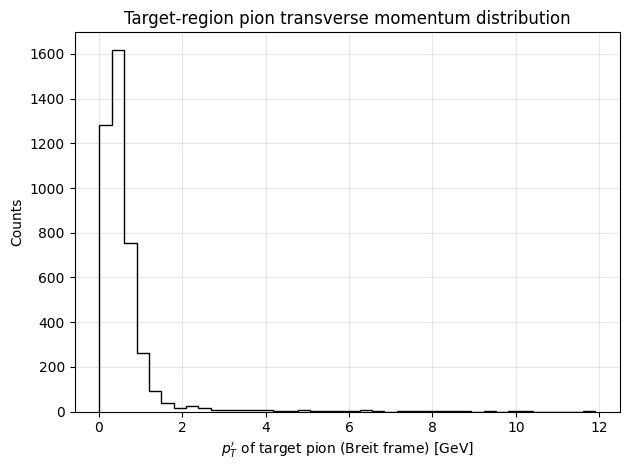

In [2]:
# ============================ Event loop =============================
for iEvent in range(n_events):

    if not pythia.next():
        continue

    ev = pythia.event

    # Identify incoming e, scattered e, proton
    e_in = e_sc = p_in = None
    for p in ev:
        if p.id() == 11 and p.status() == -12: 
            e_in = p
        elif p.id() == 11 and p.status() == 44: 
            e_sc = p
        elif p.id() == 2212 and p.status() < 0: 
            p_in = p
    if not (e_in and e_sc and p_in):
        continue

    Ee, Ep = e_in.e(), p_in.e()

    # Virtual photon
    q0 = e_in.e()  - e_sc.e()
    q1 = e_in.px() - e_sc.px()
    q2 = e_in.py() - e_sc.py()
    q3 = e_in.pz() - e_sc.pz()
    qmu = np.array([q0, q1, q2, q3])

    Q2 = -(q0*q0 - q1*q1 - q2*q2 - q3*q3)
    if Q2 <= 0: 
        continue
    Q = float(np.sqrt(Q2))

    qT = float(np.hypot(q1, q2))
    phiq = float(np.arctan2(q2, q1))
    S = 4.0*Ee*Ep

    p_dot_q = Ep*q0 - Ep*q3  # proton at (Ep, 0,0, Ep)
    x = Q2 / (2.0 * p_dot_q)
    if x <= 0:
        continue
    y = Q2 / (S * x)

    if not (Qmin <= Q <= Qmax): 
        continue
    if not (xmin <= x <= xmax): 
        continue

    n_pass_evt += 1

    # ---------------- Breit frame transform matrices ----------------
    Mm1 = np.array([
        [Ee/np.sqrt(S) + np.sqrt(S)/(4.0*Ee), 0,0, Ee/np.sqrt(S) - np.sqrt(S)/(4.0*Ee)],
        [0,1,0,0],
        [0,0,1,0],
        [Ee/np.sqrt(S) - np.sqrt(S)/(4.0*Ee), 0,0, Ee/np.sqrt(S) + np.sqrt(S)/(4.0*Ee)]
    ])

    M0 = np.array([
        [1,0,0,0],
        [0, np.cos(phiq), np.sin(phiq), 0],
        [0,-np.sin(phiq), np.cos(phiq), 0],
        [0,0,0,1]
    ])

    denom_M1 = 2.0 * y * np.sqrt(S * (-qT*qT + S*(1+x)*y))
    if denom_M1 == 0:
        continue
    M1 = np.array([
        [(-qT*qT + S*y*(1+x+y)) / denom_M1, 0,0,
         ( qT*qT + S*y*(-1-x+y)) / denom_M1],
        [0,1,0,0],
        [0,0,1,0],
        [( qT*qT + S*y*(-1-x+y)) / denom_M1, 0,0,
         (-qT*qT + S*y*(1+x+y)) / denom_M1]
    ])

    den2 = (-qT*qT + S*(1+x)*y)
    if den2 <= 0:
        continue

    denom_M2_s1 = np.sqrt(S*(1+x)*y / den2)
    denom_M2_s2 = np.sqrt(S*(1+x)*y)

    M2 = np.array([
        [1,0,0,0],
        [0,1/denom_M2_s1,0, qT/denom_M2_s2],
        [0,0,1,0],
        [0,-qT/denom_M2_s2,0,1/denom_M2_s1]
    ])

    denom_M3 = np.sqrt(den2)
    num_log = qT + np.sqrt(S*(1+x)*y)
    den_log = -qT + np.sqrt(S*(1+x)*y)
    if num_log <= 0 or den_log <= 0:
        continue

    eta = 0.5*np.log(num_log/den_log)
    M3 = np.array([
        [np.cosh(eta), -qT/denom_M3, 0,0],
        [-qT/denom_M3, np.cosh(eta), 0,0],
        [0,0,1,0],
        [0,0,0,1]
    ])

    denom_M4 = 2*np.sqrt(x*(1+x))
    if denom_M4 == 0:
        continue

    M4 = np.array([
        [(1+2*x)/denom_M4, 0,0, 1/denom_M4],
        [0,1,0,0],
        [0,0,1,0],
        [1/denom_M4, 0,0,(1+2*x)/denom_M4]
    ])

    LT = M4 @ M3 @ M2 @ M1 @ M0 @ Mm1

    def boost(v):
        return LT @ np.array(v)

    n_pass_transform += 1

    # ---------------- Find highest-E target-region pion ----------------
    best_E = -1.0
    best_trf = None

    for p in ev:
        if not p.isFinal(): 
            continue
        if not is_pion(p.id()):
            continue

        lab = np.array([p.e(), p.px(), p.py(), p.pz()])
        trf = boost(lab)

        E_, px_, py_, pz_ = trf

        # Target hemisphere
        if pz_ <= 0:
            continue

        if E_ > best_E:
            best_E = E_
            best_trf = trf

    if best_trf is None:
        continue

    n_have_target += 1

    # ---------------- Apply pT < Q/4 cut ----------------
    E_, px_, py_, pz_ = best_trf
    pT = float(np.sqrt(px_*px_ + py_*py_))

    if pT < Q/4.0:
        pT_target.append(pT)
        n_pass_cut += 1

# ============================ Output =============================
print("\n====== Target-region pion pT summary ======")
print(f"Events passing (x,Q):        {n_pass_evt}")
print(f"Events passing boost:        {n_pass_transform}")
print(f"Events with target pion:     {n_have_target}")
print(f"Events passing pT < Q/4 cut: {n_pass_cut}")
print(f"Collected pT values:         {len(pT_target)}")

# ============================ Plot =============================
plt.figure()
plt.hist(pT_target, bins=40, histtype='step', color='black')
plt.xlabel(r"$p_T'$ of target pion (Breit frame) [GeV]")
plt.ylabel("Counts")
plt.title("Target-region pion transverse momentum distribution")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("target_pion_pT.png", dpi=180)
print("Saved: target_pion_pT.png")


In [2]:
# ============================ Pythia setup ============================
pythia = pythia8.Pythia()
pythia.readString("Beams:idA = 2212")
pythia.readString("Beams:idB = 11")
#pythia.readString("Beams:eA = 275.0"); pythia.readString("Beams:eB = 18.00")
pythia.readString("Beams:eA = 920.0")
pythia.readString("Beams:eB = 28.00")
pythia.readString("Beams:frameType = 2")
pythia.readString("WeakBosonExchange:ff2ff(t:gmZ) = on")
pythia.readString("HardQCD:all = on")
pythia.readString("PDF:lepton = off")
pythia.readString("ColourReconnection:reconnect = on")   # toggle to probe color-flow
pythia.readString("PhaseSpace:Q2Min = 2025.0")
#pythia.readString("PhaseSpace:Q2Max = 3025.0")
pythia.init()

# Kinematic windows
Qmin, Qmax = 45.0, 55.0
xmin, xmax = 0.10, 0.99

# Accumulators
qT_same = []
cos_dphi_same = []
xL_list, t_list, Q_list = [], [], []

# Mixed-event pools
# store vectors + labels so we can match (x,Q,xL,t) in mixed
curr_pool = []   # (PhT_vec, zh, bX, bQ, bXL, bT)
targ_pool = []   # (PLT_vec, xL, t,  bX, bQ, bXL, bT)

# Diagnostics
n_pass_evt = n_pass_transform = 0
n_have_curr = n_have_targ = 0
n_pass_zhxL = n_pass_qT = 0

n_events = 1000000

# ============================ Event loop =============================
for iEvent in range(n_events):
    if not pythia.next():
        continue

    ev = pythia.event

    # Identify beam/scattered leptons and incoming proton
    e_in = e_sc = p_in = None
    for p in ev:
        if p.id() == 11 and p.status() == -12: e_in = p
        elif p.id() == 11 and p.status() == 44: e_sc = p
        elif p.id() == 2212 and p.status() < 0: p_in = p
    if not (e_in and e_sc and p_in): continue

    Ee, Ep = e_in.e(), p_in.e()

    # Virtual photon (lab)
    q0 = e_in.e()  - e_sc.e()
    q1 = e_in.px() - e_sc.px()
    q2 = e_in.py() - e_sc.py()
    q3 = e_in.pz() - e_sc.pz()
    qmu = np.array([q0, q1, q2, q3])

    # Invariants
    Q2 = -(q0*q0 - q1*q1 - q2*q2 - q3*q3)
    if Q2 <= 0: continue
    Q  = float(np.sqrt(Q2))
    qT = float(np.hypot(q1, q2))
    phiq = float(np.arctan2(q2, q1))
    S = 4.0*Ee*Ep

    k_l_in = np.array([Ee, 0.0, 0.0, -Ee])
    p_p_in = np.array([Ep, 0.0, 0.0,  Ep])

    p_dot_q = dot(p_p_in, qmu)
    if p_dot_q == 0.0: continue
    x = Q2 / (2.0 * p_dot_q)
    if x <= 0.0: continue
    y = Q2 / (S * x)

    if not (Qmin <= Q <= Qmax): continue
    if not (xmin <= x <= xmax): continue
    n_pass_evt += 1

    # ------------------- Breit-like transform matrices ----------------
    Mm1 = np.array([
        [Ee/np.sqrt(S) + np.sqrt(S)/(4.0*Ee), 0.0, 0.0, Ee/np.sqrt(S) - np.sqrt(S)/(4.0*Ee)],
        [0.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, 1.0, 0.0],
        [Ee/np.sqrt(S) - np.sqrt(S)/(4.0*Ee), 0.0, 0.0, Ee/np.sqrt(S) + np.sqrt(S)/(4.0*Ee)]
    ])
    M0 = np.array([
        [1, 0, 0, 0],
        [0,  np.cos(phiq),  np.sin(phiq), 0],
        [0, -np.sin(phiq),  np.cos(phiq), 0],
        [0, 0, 0, 1]
    ])

    denom_M1 = 2.0 * y * np.sqrt(S * (-qT**2 + S * (1.0 + x) * y))
    if denom_M1 == 0.0: continue
    M1 = np.array([
        [(-qT**2 + S*y*(1.0 + x + y)) / denom_M1, 0, 0, ( qT**2 + S*y*(-1.0 - x + y)) / denom_M1],
        [0, 1., 0, 0],
        [0, 0, 1., 0],
        [( qT**2 + S*y*(-1.0 - x + y)) / denom_M1, 0, 0, (-qT**2 + S*y*(1.0 + x + y)) / denom_M1]
    ])

    den2 = (-qT**2 + S*(1.0 + x)*y)
    if den2 <= 0.0: continue
    denom_M2_s1 = np.sqrt(S * (1.0 + x) * y / den2)
    denom_M2_s2 = np.sqrt(S * (1.0 + x) * y)
    if denom_M2_s1 == 0.0 or denom_M2_s2 == 0.0: continue
    M2 = np.array([
        [1, 0, 0, 0],
        [0, 1.0/denom_M2_s1, 0, qT/denom_M2_s2],
        [0, 0, 1, 0],
        [0, -qT/denom_M2_s2, 0, 1.0/denom_M2_s1]
    ])

    denom_M3_sqrt = np.sqrt(den2)
    numer_M3_log = qT + np.sqrt(S * (1.0 + x) * y)
    denom_M3_log = -qT + np.sqrt(S * (1.0 + x) * y)
    if denom_M3_log <= 0.0 or numer_M3_log <= 0.0: continue
    cosh_arg = numer_M3_log / denom_M3_log
    M3 = np.array([
        [np.cosh(0.5 * np.log(cosh_arg)), -qT / denom_M3_sqrt, 0, 0],
        [-qT / denom_M3_sqrt, np.cosh(0.5 * np.log(cosh_arg)), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

    if x*(1.0 + x) <= 0.0: continue
    denom_M4 = 2.0 * np.sqrt(x * (1.0 + x))
    M4 = np.array([
        [(1.0 + 2.0*x) / denom_M4, 0, 0, 1.0/denom_M4],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [1.0/denom_M4, 0, 0, (1.0 + 2.0*x) / denom_M4]
    ])

    LT = M4 @ M3 @ M2 @ M1 @ M0 @ Mm1

    def apply_LT(E, px, py, pz):
        v = LT @ np.array([E, px, py, pz])
        return np.array([v[0], v[1], v[2], v[3]])  # (E', px', py', pz')

    # ---------------- Collect finals & transform stepwise --------------
    finals = []  # (lab4, trf4, pid)
    for p in ev:
        if not p.isFinal(): continue
        if abs(p.id()) == 11: continue  # drop leptons
        lab = np.array([p.e(), p.px(), p.py(), p.pz()])
        trf = apply_LT(*lab)
        finals.append((lab, trf, p.id()))
    if not finals: continue
    n_pass_transform += 1

    # ------------------ Tag current & target (hadron-only) -------------
    # Current/backward (Breit): pick hadron with max pT' and pz' < 0
    curr_cand = None; best_pt2_curr = -1.0
    for lab, trf, pid in finals:
        if not is_hadron(pid): continue
        E, px, py, pz = trf
        if pz >= 0.0: continue
        pT2 = px*px + py*py
        if pT2 > best_pt2_curr:
            best_pt2_curr = pT2
            curr_cand = (lab, trf, pid)

    # Target/forward (Breit): pick hadron with max E' and pz' > 0
    targ_cand = None; best_E_targ = -1.0
    for lab, trf, pid in finals:
        if not is_hadron(pid): continue
        E, px, py, pz = trf
        if pz <= 0.0: continue
        if E > best_E_targ:
            best_E_targ = E
            targ_cand = (lab, trf, pid)

    if curr_cand is None or targ_cand is None:
        continue
    n_have_curr += 1
    n_have_targ += 1

    # Require both tags to be charged pions
    lab_h, trf_h, pid_h = curr_cand
    lab_L, trf_L, pid_L = targ_cand
    if not (is_pion(pid_h) and is_pion(pid_L)):
        continue

    lab_h, trf_h, _ = curr_cand
    lab_L, trf_L, _ = targ_cand

    # --------------------- Compute z_h, x_L, t (lab) ------------------
    zh  = dot(p_p_in, lab_h) / p_dot_q
    xL  = lab_L[0] / Ep if Ep > 0 else 0.0
    t4  = p_p_in - lab_L
    tval = dot(t4, t4)

    # --- NEW: acceptance cuts to tame 1/zh and 1/xL and focus on leading forward ---
    if (zh <= zh_min) or (xL <= xL_min):
        continue
    if abs(tval) > t_abs_max:
        continue
    n_pass_zhxL += 1

#    # after you set PhT, PLT from the transformed 4-vectors
#    if np.linalg.norm(PhT) > PhT_max or np.linalg.norm(PLT) > PLT_max:
#        continue

    # --------------------- Build qT imbalance (Breit) ------------------
    Eh, pxh, pyh, pzh = trf_h
    EL, pxL, pyL, pzL = trf_L
    PhT = np.array([pxh, pyh])
    PLT = np.array([pxL, pyL])

    khT = PhT/zh
    kLT = PLT/xL

    qT_vec = khT + kLT
    qTmag  = float(np.linalg.norm(qT_vec))

    # record r = qT/Q for each pion-pair charge combination
    r = qTmag / Q
    ch_h, ch_L = charge(pid_h), charge(pid_L)
    if   ch_h ==  1 and ch_L ==  1: r_by_pair["++"].append(r)
    elif ch_h ==  1 and ch_L == -1: r_by_pair["+-"].append(r)
    elif ch_h == -1 and ch_L ==  1: r_by_pair["-+"].append(r)
    elif ch_h == -1 and ch_L == -1: r_by_pair["--"].append(r)

    # NEW: cap tag pT in Breit frame to stay in TMD-ish region
    if qTmag/Q > r_max:
        continue

    dphi = (phimod(pxh, pyh) - phimod(pxL, pyL) + np.pi) % (2*np.pi) - np.pi
    cos_dphi = float(np.cos(dphi))

    # TMD hygiene (start loose; tighten later if desired)
    if qTmag < Q:
        qT_same.append(qTmag)
        cos_dphi_same.append(cos_dphi)
        xL_list.append(float(xL))
        t_list.append(float(tval))
        Q_list.append(float(Q))
        n_pass_qT += 1

    # ----------------- Mixed-event pools with bin labels ----------------
    bX  = bin_x(x)
    bQ  = bin_Q(Q)
    bXL = bin_xL(xL)
    bT  = bin_t(tval)
    curr_pool.append((PhT.copy(), float(zh), bX, bQ, bXL, bT))
    targ_pool.append((PLT.copy(), float(xL), float(tval), bX, bQ, bXL, bT))

# ========================= Mixed-event baseline ======================
rng = np.random.default_rng(42)
n_mix = min(len(curr_pool), len(targ_pool))
qT_mix = []; cos_dphi_mix = []

if n_mix > 200:
    ci = rng.permutation(n_mix)
    ti = rng.permutation(n_mix)
    for i in range(n_mix):
        PhT, zh_i, bX_i, bQ_i, bXL_i, bT_i = curr_pool[ci[i]]
        PLT, xL_j, t_j,  bX_j, bQ_j, bXL_j, bT_j = targ_pool[ti[i]]

        # match (x, Q, xL, t) bins to make a fair baseline
        if (bX_i != bX_j) or (bQ_i != bQ_j) or (bXL_i != bXL_j) or (bT_i != bT_j):
            continue

        qTv  = PhT/zh_i + PLT/xL_j
        qTval = float(np.linalg.norm(qTv))

        dphi = (phimod(PhT[0], PhT[1]) - phimod(PLT[0], PLT[1]) + np.pi) % (2*np.pi) - np.pi
        cos_dphi_mix.append(float(np.cos(dphi)))
        qT_mix.append(qTval)

# ============================= Summaries =============================
def mean_std(arr):
    if len(arr) == 0: return (np.nan, np.nan)
    a = np.array(arr, dtype=float)
    return float(a.mean()), float(a.std(ddof=1)) if len(a) > 1 else (float(a.mean()), 0.0)

mqS, sqS = mean_std(qT_same)
mcS, scS = mean_std(cos_dphi_same)

print("\n=========== qT imbalance quick-look (Breit frame) ===========")
print(f"Same-event sample size: {len(qT_same)}")
print(f"<qT>_same = {mqS:.3f} GeV,  σ(qT)_same = {sqS:.3f} GeV")
print(f"<cosΔφ>_same = {mcS:.3f}  (back-to-back → -1)")

if len(qT_mix) > 50:
    mqM, sqM = mean_std(qT_mix)
    mcM, scM = mean_std(cos_dphi_mix)
    print("\nMixed-event baseline:")
    print(f"<qT>_mix  = {mqM:.3f} GeV,  σ(qT)_mix  = {sqM:.3f} GeV")
    print(f"<cosΔφ>_mix = {mcM:.3f}")
    print("\nConnected excess (same − mix):")
    print(f"Δ<qT>     = {mqS - mqM:+.3f} GeV")
    print(f"Δ<cosΔφ>  = {mcS - mcM:+.3f}")
else:
    print("\nMixed-event baseline not formed (need >200 pooled pairs).")

print("\n---- Selection diagnostics ----")
print(f"pass (x,Q):            {n_pass_evt}")
print(f"pass transform:        {n_pass_transform}")
print(f"have current tag:      {n_have_curr}")
print(f"have target tag:       {n_have_targ}")
print(f"pass zh/xL/|t| cuts:   {n_pass_zhxL}")
print(f"pass qT < Q:           {n_pass_qT}")

pythia.stat()

# ============================= Charge-pair ratios =============================
def safe_div(a, b, eps=1e-12):
    return np.divide(a, b + eps, out=np.zeros_like(a), where=(b > eps))

n_rbins = 20
r_edges = np.linspace(0.0, r_max, n_rbins + 1)
r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])

H_pp, _ = np.histogram(r_by_pair["++"], bins=r_edges)
H_pm, _ = np.histogram(r_by_pair["+-"], bins=r_edges)
H_mp, _ = np.histogram(r_by_pair["-+"], bins=r_edges)
H_mm, _ = np.histogram(r_by_pair["--"], bins=r_edges)

H_den = 0.5 * (H_pm + H_mp)
R_pp = safe_div(H_pp, H_den)
R_mm = safe_div(H_mm, H_den)

print("\n=========== π-charge pair ratios vs r = qT/Q ===========")
print(f"Counts: ++={H_pp.sum()}, +-={H_pm.sum()}, -+={H_mp.sum()}, --={H_mm.sum()}")
print("r centers:", np.array2string(r_centers, precision=3, separator=', '))
print("R_pp(r):", np.array2string(R_pp, precision=3, separator=', '))
print("R_mm(r):", np.array2string(R_mm, precision=3, separator=', '))



 *------------------------------------------------------------------------------------* 
 |                                                                                    | 
 |  *------------------------------------------------------------------------------*  | 
 |  |                                                                              |  | 
 |  |                                                                              |  | 
 |  |   PPP   Y   Y  TTTTT  H   H  III    A      Welcome to the Lund Monte Carlo!  |  | 
 |  |   P  P   Y Y     T    H   H   I    A A     This is PYTHIA version 8.312      |  | 
 |  |   PPP     Y      T    HHHHH   I   AAAAA    Last date of change: 23 May 2024  |  | 
 |  |   P       Y      T    H   H   I   A   A                                      |  | 
 |  |   P       Y      T    H   H  III  A   A    Now is 22 Oct 2025 at 12:21:58    |  | 
 |  |                                                                              |  | 
 |  |   Program docu

KeyboardInterrupt: 

Saved: Splus_qT_over_Q.png


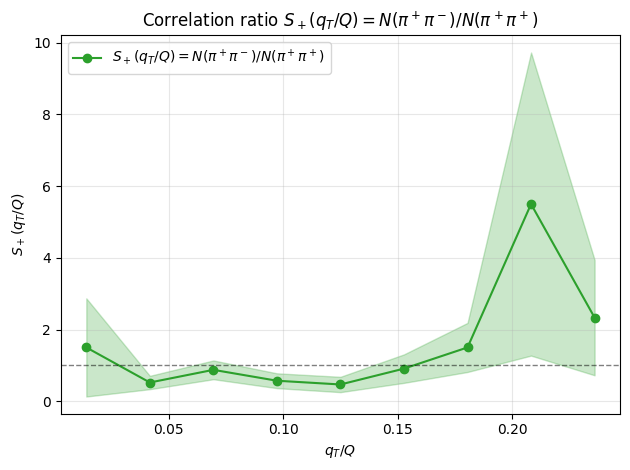

In [10]:
# ============================== Plots ===============================
import matplotlib.pyplot as plt
import numpy as np

# 4) Signal ratio S+(qT/Q) = N(pi+pi-)/N(pi+pi+)
plt.figure()

if len(r_by_pair["+-"]) > 0 and len(r_by_pair["++"]) > 0:
    # choose binning over r = qT/Q range
    qt_bins = np.linspace(0.0, r_max, 10)
    qt_centers = 0.5 * (qt_bins[:-1] + qt_bins[1:])

    # histogram COUNTS (no density normalization)
    N_pm, _ = np.histogram(r_by_pair["+-"], bins=qt_bins)
    N_pp, _ = np.histogram(r_by_pair["++"], bins=qt_bins)

    # signal ratio S+
    S_plus = np.divide(N_pm, N_pp, out=np.full_like(N_pp, np.nan, dtype=float), where=(N_pp > 0))

    # statistical uncertainty: σ(S) ≈ S * sqrt(1/N_pm + 1/N_pp)
    sig_S_plus = np.full_like(S_plus, np.nan, dtype=float)
    mask = (N_pm > 0) & (N_pp > 0)
    sig_S_plus[mask] = S_plus[mask] * np.sqrt(1.0 / N_pm[mask] + 1.0 / N_pp[mask])

    # plot
    plt.plot(qt_centers, S_plus, 'o-', color='tab:green',
             label=r'$S_+(q_T/Q) = N(\pi^+\pi^-)/N(\pi^+\pi^+)$')
    plt.fill_between(qt_centers, S_plus - sig_S_plus, S_plus + sig_S_plus,
                     color='tab:green', alpha=0.25)

    # cosmetics
    plt.axhline(1.0, color='k', linestyle='--', linewidth=1.0, alpha=0.5)
    plt.xlabel(r'$q_T / Q$')
    plt.ylabel(r'$S_+(q_T/Q)$')
    plt.title(r'Correlation ratio $S_+(q_T/Q) = N(\pi^+\pi^-)/N(\pi^+\pi^+)$')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('Splus_qT_over_Q.png', dpi=180)
    print("Saved: Splus_qT_over_Q.png")

else:
    print("Not enough π⁺π⁺ or π⁺π⁻ pairs to form S+(qT/Q).")



Saved plots: qT_dist.png, cosDeltaPhi_dist.png, qT_over_Q_dist.png


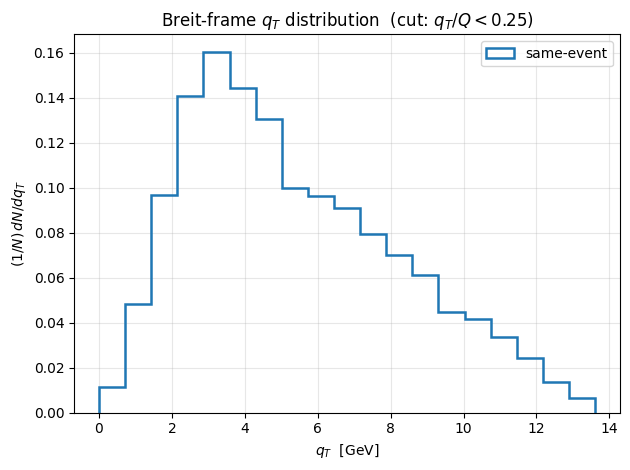

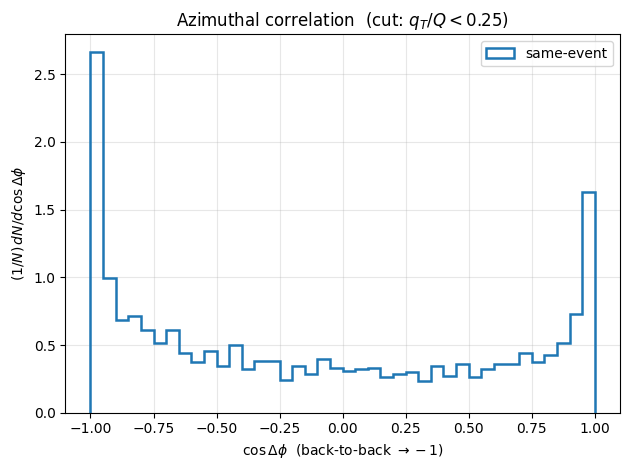

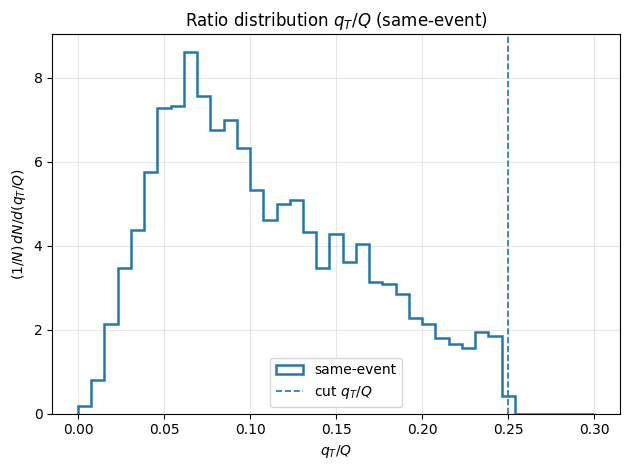

In [9]:
# ============================== Plots ===============================
import matplotlib.pyplot as plt

def safe_max(lst, fallback=1.0):
    return float(np.max(lst)) if len(lst) else fallback

# 1) q_T distribution (same vs mixed)
qt_max = max(safe_max(qT_same, 1.0), safe_max(qT_mix, 1.0))
qt_max = min(qt_max, 20.0)  # keep x-axis reasonable
bins_qt = np.linspace(0.0, qt_max, 20)

plt.figure()
if len(qT_same):
    plt.hist(qT_same, bins=bins_qt, histtype='step', linewidth=1.8,
             density=True, label='same-event')
if len(qT_mix) > 50:
    plt.hist(qT_mix, bins=bins_qt, histtype='step', linewidth=1.2,
             density=True, label='mixed-event')
plt.xlabel(r'$q_T$  [GeV]')
plt.ylabel(r'$(1/N)\, dN/dq_T$')
plt.title('Breit-frame $q_T$ distribution' + (f'  (cut: $q_T/Q<{r_max:.2f}$)' if "r_max" in globals() else ''))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('qT_dist.png', dpi=180)

# 2) cos(Δφ) distribution (same vs mixed)
bins_phi = np.linspace(-1.0, 1.0, 41)
plt.figure()
if len(cos_dphi_same):
    plt.hist(cos_dphi_same, bins=bins_phi, histtype='step', linewidth=1.8,
             density=True, label='same-event')
if len(qT_mix) > 50:
    plt.hist(cos_dphi_mix, bins=bins_phi, histtype='step', linewidth=1.2,
             density=True, label='mixed-event')
plt.xlabel(r'$\cos\Delta\phi$  (back-to-back $\to -1$)')
plt.ylabel(r'$(1/N)\, dN/d\cos\Delta\phi$')
plt.title('Azimuthal correlation' + (f'  (cut: $q_T/Q<{r_max:.2f}$)' if "r_max" in globals() else ''))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cosDeltaPhi_dist.png', dpi=180)

# 3) q_T / Q distribution (same-event only; mixed needs Q per pair)
if len(qT_same) and len(Q_list) == len(qT_same):
    r_vals = np.array(qT_same) / np.array(Q_list)
    r_max_plot = min(float(np.max(r_vals)), 1.0)
    bins_r = np.linspace(0.0, max(0.3, r_max_plot), 40)

    plt.figure()
    plt.hist(r_vals, bins=bins_r, histtype='step', linewidth=1.8,
             density=True, label='same-event')
    if "r_max" in globals():
        plt.axvline(r_max, linestyle='--', linewidth=1.2, label=r'cut $q_T/Q$')
    plt.xlabel(r'$q_T / Q$')
    plt.ylabel(r'$(1/N)\, dN/d(q_T/Q)$')
    plt.title(r'Ratio distribution $q_T/Q$ (same-event)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('qT_over_Q_dist.png', dpi=180)

print("\nSaved plots: qT_dist.png, cosDeltaPhi_dist.png, qT_over_Q_dist.png")


Saved: dsigma_d2qT.png


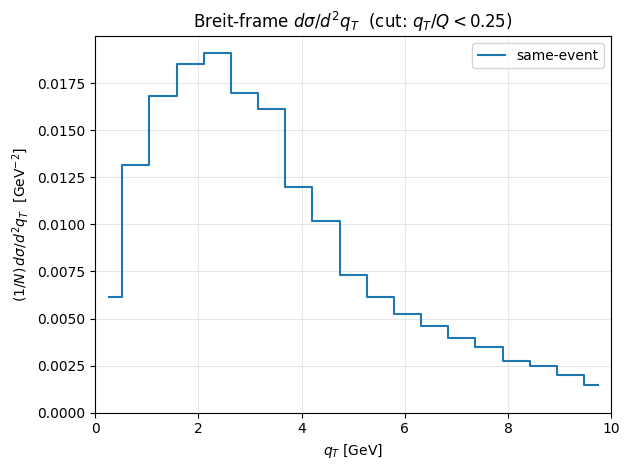

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- dσ/d²qT instead of qT dσ/d²qT ----------
bins_qt = np.linspace(0.0, 10.0, 20)
bin_centers = 0.5 * (bins_qt[1:] + bins_qt[:-1])
bin_widths = np.diff(bins_qt)

def dsig_d2qt(sample, label, color=None):
    counts, _ = np.histogram(sample, bins=bins_qt)
    norm = np.sum(counts * bin_widths)  # normalize to 1 if you like
    f = counts / (2*np.pi*bin_centers*bin_widths)  # divide by Jacobian
    plt.step(bin_centers, f / norm, where='mid', label=label, color=color)

plt.figure()
if len(qT_same):
    dsig_d2qt(qT_same, 'same-event')
if len(qT_mix) > 50:
    dsig_d2qt(qT_mix, 'mixed-event')

plt.xlabel(r'$q_T$ [GeV]')
plt.ylabel(r'$(1/N)\, d\sigma/d^2q_T$  [GeV$^{-2}$]')
plt.title(r'Breit-frame $d\sigma/d^2q_T$' + f'  (cut: $q_T/Q<{r_max:.2f}$)')
plt.xlim(0, 10)
plt.ylim(bottom=0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dsigma_d2qT.png', dpi=180)
print("Saved: dsigma_d2qT.png")
